# 7주차_컨볼루션_신경망과_컴퓨터_비전

- Preview
- 컨볼루션 신경망의 동기와 전개
- 컨볼루션 신경망의 구조와 동작
- 컨볼루션 신경망의 학습
- 컨볼루션 신경망 프로그래밍
- 컨볼루션 신경망의 시각화
- 딥러닝의 규제
- 전이 학습
- 물체 검출

---

# 📌 CNN의 연산 순서 (전형적 구조 기준)

## 1️⃣ 입력(Input)

- 이미지 또는 피처 맵 형태의 데이터 (예: 32×32×3 RGB 이미지)

## 2️⃣ 패딩(Padding, 선택적 과정)

- 입력 데이터 주변을 0으로 감싸는 작업 (Zero Padding)
- 컨볼루션 이후 출력 크기 유지 및 가장자리 정보 보존 목적

> 예시:
> 
> - 입력: 32×32, 커널 크기: 3×3, 패딩: 1 → 출력: 32×32 (크기 유지)

## 3️⃣ 컨볼루션(Convolution)

- 필터(커널)를 입력 이미지 또는 피처 맵 위에 겹쳐 슬라이딩하면서 특징을 추출하는 연산
- 주요 설정 요소는 커널 크기, 스트라이드(stride), 패딩

### 🔹 컨볼루션 출력 크기 계산 공식

출력크기=입력크기−커널크기+2×패딩스트라이드+1출력크기 = \frac{입력크기 - 커널크기 + 2 \times 패딩}{스트라이드} + 1

출력크기=스트라이드입력크기−커널크기+2×패딩+1

- 예시:
    - 입력: 32×32, 커널: 3×3, 패딩: 1, 스트라이드: 1
        
        → 출력: 32×32 (출력 크기 유지됨)
        

## 4️⃣ 비선형 활성화 함수 (Activation Function)

- 컨볼루션의 결과에 비선형성(Non-linearity)을 추가하여 모델의 표현력을 높이는 과정
- 주로 ReLU(Rectified Linear Unit)를 사용하여 음수 값을 제거하고 양수 값만 유지하는 연산

## 5️⃣ 풀링(Pooling)

- 특징 맵의 공간적 크기를 축소하여 연산량과 과적합 위험을 감소시키는 작업
- 주로 Max Pooling 방식을 사용하여 국소적 특징을 유지하면서 크기 축소 수행

> 예시: 2×2 Max Pooling, 스트라이드=2
> 
> 
> → 가로·세로가 각각 절반 크기로 축소됨 (32×32 → 16×16)
> 

## 🔄 반복 (Conv + ReLU + Pooling)

- 위 과정을 여러 번 반복하여 저수준(Low-level)에서 고수준(High-level)의 특징을 점진적으로 추출하는 과정
- **반복(🔄)**이 의미하는 것은 하나의 작은 구조적 단위, 즉 **빌딩 블록(Building Block)**을 여러 번 반복적으로 사용한다는 뜻

## 6️⃣ 펼침(Flatten)

- 다차원으로 생성된 특징 맵을 일차원 벡터로 변환하는 과정
- 이후 Fully Connected Layer(완전 연결층) 입력 형태로 사용

## 7️⃣ 완전 연결층 (Fully Connected Layer)

- 펼친 특징 벡터를 기존의 다층 퍼셉트론(MLP) 방식과 동일하게 입력받아 학습 및 예측을 수행하는 층
- 주로 분류 작업 수행 목적

## 8️⃣ 소프트맥스(Softmax, 선택적 과정)

- 최종 출력층에서 사용하여 클래스별 확률을 제공하는 활성화 함수
- 분류 문제에서 최종 예측값으로 클래스 확률 반환

---

# 📌 CNN 구조에서 다중 커널(Multiple Kernels) 활용 개념

## 🔹 입력 텐서 형태

- 형태: $M \times N \times k$ (가로×세로×채널)
- 예시: 512×512 RGB 이미지 → 512×512×3 텐서

## 🔹 커널 텐서 형태

- 형태: $h \times h \times k$, 커널 크기(h×h) 및 입력 채널(k)에 걸친 3차원 형태
- 다중 커널 사용 시 각 커널이 독립적으로 입력 텐서와 컨볼루션 연산 수행

## 🔹 출력 텐서 형태

- 형태: $M' \times N' \times k'$
- $k′$
: 사용된 커널 개수
- 각 커널이 생성한 2D 특징 맵이 채널 방향으로 쌓여 다차원 텐서를 형성

## 🔹 컨볼루션 연산의 계산량

- 입력 크기 및 커널 크기에 비례한 곱셈 연산 수 발생
- 예시: 입력 (512×512×3), 커널 (3×3×3)

1️⃣ 출력 Feature Map 크기 계산 (가로 × 세로):

공식:

$\text{출력 크기} = \frac{(입력크기 - 커널크기 + 2 \times 패딩)}{\text{stride}} + 1$

$= \frac{(512 - 3 + 0)}{1} + 1 = 510$

→ 출력 Feature Map 크기 = **510 × 510**



2️⃣ 한 위치에서 수행되는 곱셈의 수:

- 커널 크기: 3×3×3 = **27개 원소**
- 즉, 한 위치에서 입력과 커널 간 곱셈 27회, 이들을 모두 합산 (덧셈 26회)



3️⃣ 전체 위치 수:

- 총 위치 수 = 출력 Feature Map의 픽셀 수 = **510 × 510 = 260,100**



✅ 최종 곱셈 수:

$총 곱셈 수 = 위치 수 × 커널 요소 수 = 260,100 × 27 = \boxed{7,022,700}$

→ 곱셈 연산 수: 약 700만 회 이상 발생

## 🔹 활성화 함수 적용

- 비선형 활성화 함수(ReLU 등)를 통해 컨볼루션 결과를 변형하여 비선형 특징 맵 생성
- 연산 수식 형태:τ(f(j,i))=τ(z(j,i)⊗u)
    
    $\tau(f(j,i)) = \tau(z(j,i) \otimes u)$
    
    - ⊗: 컨볼루션 연산
    - τ: 활성화 함수 (예: ReLU)
    - z(j,i): 입력 텐서 내 특정 위치의 로컬 영역
    - u: 커널 (필터)

---


# 📌 컨볼루션(Convolution) 연산의 계산량

CNN의 컨볼루션 연산에서 계산량은 다음 요소에 따라 결정.

- 입력 이미지 크기(가로 × 세로 × 채널)
- 커널(필터)의 크기(가로 × 세로 × 입력 채널)
- 커널의 개수(생성할 Feature map 채널 수)
- 패딩(padding) 종류 및 크기
- 스트라이드(stride)

---

## ✅ 컨볼루션 연산 계산법

컨볼루션 연산 계산 과정은 다음과 같습니다.

**(1) 출력 Feature Map 크기 계산**

$\text{출력 크기} = \frac{(입력 크기 - 커널 크기 + 2 \times 패딩)}{\text{스트라이드}} + 1$

- 위 수식을 가로 및 세로 방향 각각 적용하여 출력 크기를 결정합니다.

**(2) 위치당 연산 수**

한 위치에서 커널과 입력 간 곱셈 연산 수는:

$\text{커널 가로 크기} \times \text{커널 세로 크기} \times \text{입력 채널 수}$

**(3) 총 연산 수**

최종적으로 전체 곱셈 연산 수는:

$\text{총 연산 수} = \text{출력 가로 크기} \times \text{출력 세로 크기} \times \text{(커널 가로 크기 × 커널 세로 크기 × 입력 채널 수)} \times \text{커널 개수}$

---

## 📝 다양한 조건별 예시 (계산 과정 포함)

### 🔹 예시 1 (기본 조건)

- 입력 크기: 512×512×3
- 커널 크기: 3×3×3
- 커널 개수: 1개
- 패딩: 0 (없음)
- 스트라이드: 1

| 항목 | 계산 결과 |
| --- | --- |
| 출력 크기 | (512−3+0)/1+1=510×510 |
| 위치당 곱셈 수 | 3×3×3=27 |
| 총 연산 수 | 510×510×27×1=7,022,700 |

→ **총 약 702만 회 곱셈**

---

### 🔹 예시 2 (패딩 적용)

- 입력 크기: 512×512×3
- 커널 크기: 3×3×3
- 커널 개수: 1개
- 패딩: 1 (same padding, 출력 크기 유지)
- 스트라이드: 1

| 항목 | 계산 결과 |
| --- | --- |
| 출력 크기 | (512−3+2×1)/1+1=512×512 |
| 위치당 곱셈 수 | 3×3×3=27 |
| 총 연산 수 | 512×512×27×1=7,077,888 |

→ **총 약 708만 회 곱셈**

---

### 🔹 예시 3 (스트라이드 변경)

- 입력 크기: 512×512×3
- 커널 크기: 3×3×3
- 커널 개수: 1개
- 패딩: 0 (없음)
- 스트라이드: 2

| 항목 | 계산 결과 |
| --- | --- |
| 출력 크기 | (512−3+0)/2+1=255×255 |
| 위치당 곱셈 수 | 3×3×3=27 |
| 총 연산 수 | 255×255×27×1=1,755,675 |

→ **총 약 176만 회 곱셈** (계산량 크게 감소)

---

### 🔹 예시 4 (커널 개수 증가)

- 입력 크기: 512×512×3
- 커널 크기: 3×3×3
- 커널 개수: 64개
- 패딩: 1 (same padding)
- 스트라이드: 1

| 항목 | 계산 결과 |
| --- | --- |
| 출력 크기 | (512−3+2×1)/1+1=512×512 |
| 위치당 곱셈 수 | 3×3×3=27 |
| 총 연산 수 | 512×512×27×64=452,984,832 |

→ **총 약 4억 5천만 회 곱셈** (커널 개수 증가에 따라 크게 증가)

---

## 🚨 결과 비교 표 (직관적 이해)

| 조건 | 출력 크기 | 곱셈 수 (약) |
| --- | --- | --- |
| 기본 (패딩X, stride=1, 커널=1) | 510×510 | 702만 |
| 패딩 추가 (패딩=1) | 512×512 | 708만 |
| 스트라이드 증가 (stride=2) | 255×255 | 176만 |
| 커널 증가 (패딩=1, 커널=64) | 512×512×64 | 4억 5천만 |
- **패딩 적용 시**: 출력 크기 유지되면서 연산량 약간 증가
- **스트라이드 증가 시**: 출력 크기 감소하여 연산량 크게 감소
- **커널 수 증가 시**: 연산량 매우 크게 증가

---

## 📌 최종 요약 (CNN 설계 시 주의점)

- **커널 크기↑** → 연산량 증가 (단, 상대적으로 위치 수 감소)
- **패딩 적용** → 출력 크기 유지, 연산량 약간 증가
- **스트라이드 증가** → 출력 크기 및 연산량 대폭 감소
- **커널 수 증가** → 연산량 비례적으로 크게 증가

이러한 계산을 바탕으로 CNN 모델을 설계할 때 효율성과 성능 간 균형을 찾는 것이 중요.

In [ ]:
# ------------------------------------------------------------
# [전체 개요]
# 본 코드는 LeNet-5 아키텍처 기반의 CNN 모델을 사용하여
# MNIST 손글씨 숫자 이미지 데이터를 분류하는 학습 과정을 수행함.
#
# [처리 순서]
# 1. 필요한 라이브러리 불러오기
# 2. MNIST 데이터셋 로드 및 전처리 (정규화, 원-핫 인코딩)
# 3. LeNet-5 기반 CNN 모델 정의
# 4. 모델 컴파일 및 학습 진행
# 5. 테스트 데이터로 성능 평가
# 6. 학습 정확률 및 손실 시각화
# ------------------------------------------------------------

import numpy as np  # 수치 계산과 배열 연산을 위한 numpy 모듈 불러오기
import tensorflow as tf  # 딥러닝 프레임워크 TensorFlow 모듈 불러오기
from tensorflow.keras.datasets import mnist  # MNIST 데이터셋 로드를 위한 모듈 불러오기
from tensorflow.keras.models import Sequential  # 순차적 모델 생성을 위한 모듈 불러오기
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense  # CNN 구성 레이어들 불러오기
from tensorflow.keras.optimizers import Adam  # Adam 최적화 알고리즘 불러오기

# MNIST 데이터셋 로드 및 훈련/테스트 데이터 분할
(x_train, y_train), (x_test, y_test) = mnist.load_data()  # 데이터셋 로드 및 분할 수행

# 훈련 이미지 데이터의 차원을 CNN 입력 형식에 맞도록 (28, 28, 1)로 변환
x_train = x_train.reshape(60000, 28, 28, 1)  # 훈련용 이미지 차원 변환
x_test = x_test.reshape(10000, 28, 28, 1)  # 테스트용 이미지 차원 변환

# 입력 이미지 픽셀 값을 0~255 범위에서 0~1 범위로 정규화
x_train = x_train.astype(np.float32) / 255.0  # 훈련 데이터 정규화
x_test = x_test.astype(np.float32) / 255.0  # 테스트 데이터 정규화

# 정답 레이블을 원-핫 인코딩 형식으로 변환 (10개의 클래스)
y_train = tf.keras.utils.to_categorical(y_train, 10)  # 훈련 레이블 원-핫 인코딩
y_test = tf.keras.utils.to_categorical(y_test, 10)  # 테스트 레이블 원-핫 인코딩

# LeNet-5 기반의 CNN 모델 설계
cnn = Sequential()  # 순차적 모델 객체 생성

# 첫 번째 Convolution Layer: 필터 수 6개, 커널 크기 5x5, padding=same, 활성화 함수 ReLU
cnn.add(Conv2D(6, (5, 5), padding='same', activation='relu', input_shape=(28, 28, 1)))  # 첫 번째 합성곱층 추가

# 첫 번째 Max Pooling Layer: 풀링 크기 2x2
cnn.add(MaxPooling2D(pool_size=(2, 2)))  # 첫 번째 풀링층 추가

# 두 번째 Convolution Layer: 필터 수 16개, 커널 크기 5x5, padding=same, 활성화 함수 ReLU
cnn.add(Conv2D(16, (5, 5), padding='same', activation='relu'))  # 두 번째 합성곱층 추가

# 두 번째 Max Pooling Layer: 풀링 크기 2x2
cnn.add(MaxPooling2D(pool_size=(2, 2)))  # 두 번째 풀링층 추가

# 세 번째 Convolution Layer: 필터 수 120개, 커널 크기 5x5, padding=same, 활성화 함수 ReLU
cnn.add(Conv2D(120, (5, 5), padding='same', activation='relu'))  # 세 번째 합성곱층 추가

# 특징 맵을 일렬로 펼치는 Flatten Layer
cnn.add(Flatten())  # Flatten 층 추가

# 첫 번째 Fully Connected Layer: 출력 노드 수 84개, 활성화 함수 ReLU
cnn.add(Dense(84, activation='relu'))  # 첫 번째 완전연결층 추가

# 두 번째 Fully Connected Layer (출력층): 클래스 수 10개, 활성화 함수 softmax
cnn.add(Dense(10, activation='softmax'))  # 출력층 추가

# 모델 컴파일: 손실 함수로 categorical_crossentropy, 최적화 기법으로 Adam 사용, 평가 지표로 accuracy 설정
cnn.compile(loss='categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])  # 모델 컴파일

# 모델 학습: 배치 사이즈 128, 총 30 epoch 동안 학습 수행, 검증 데이터로 테스트셋 사용
hist = cnn.fit(x_train, y_train, batch_size=128, epochs=30,
               validation_data=(x_test, y_test), verbose=2)  # 모델 학습 수행

# 테스트 데이터셋을 이용한 모델 평가
res = cnn.evaluate(x_test, y_test, verbose=0)  # 테스트 정확률 평가
print("정확률은", res[1] * 100)  # 정확률(%) 출력

import matplotlib.pyplot as plt  # 시각화를 위한 matplotlib.pyplot 모듈 불러오기

# 정확률 그래프 시각화
plt.plot(hist.history['accuracy'])  # 훈련 데이터 정확률 플롯
plt.plot(hist.history['val_accuracy'])  # 검증 데이터 정확률 플롯
plt.title('Model accuracy')  # 그래프 제목 설정
plt.ylabel('Accuracy')  # y축 라벨 설정
plt.xlabel('Epoch')  # x축 라벨 설정
plt.legend(['Train', 'Validation'], loc='best')  # 범례 설정
plt.grid()  # 격자 표시
plt.show()  # 그래프 출력

# 손실 함수 그래프 시각화
plt.plot(hist.history['loss'])  # 훈련 데이터 손실 플롯
plt.plot(hist.history['val_loss'])  # 검증 데이터 손실 플롯
plt.title('Model loss')  # 그래프 제목 설정
plt.ylabel('Loss')  # y축 라벨 설정
plt.xlabel('Epoch')  # x축 라벨 설정
plt.legend(['Train', 'Validation'], loc='best')  # 범례 설정
plt.grid()  # 격자 표시
plt.show()  # 그래프 출력


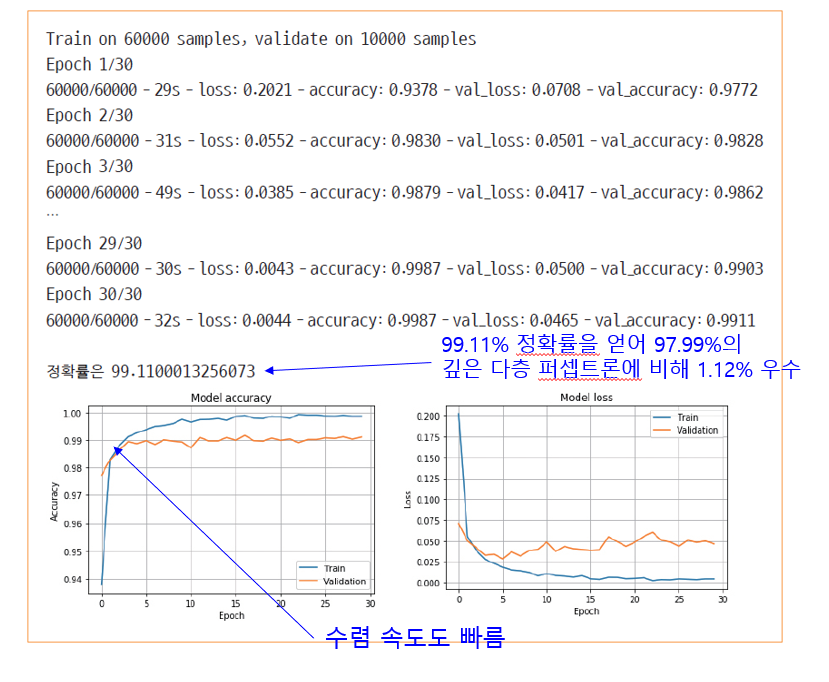

In [ ]:
# ------------------------------------------------------------
# [전체 개요]
# 본 코드는 CNN(합성곱 신경망)을 이용하여 MNIST 숫자 이미지 데이터셋을 분류하는 학습 예제임.
#
# [처리 순서]
# 1. 라이브러리 불러오기 및 MNIST 데이터셋 로드
# 2. 입력 데이터 전처리 (형상 변환, 정규화, 원-핫 인코딩)
# 3. CNN 모델 설계 (Conv2D + MaxPooling + Dropout + Dense)
# 4. 모델 컴파일 및 학습 수행
# 5. 테스트 데이터셋을 이용한 정확률 평가
# 6. 정확률 및 손실 시각화 그래프 출력
# ------------------------------------------------------------

import numpy as np  # 수치 연산 및 배열 처리를 위한 numpy 모듈 불러오기
import tensorflow as tf  # 딥러닝 구현을 위한 TensorFlow 모듈 불러오기
from tensorflow.keras.datasets import mnist  # MNIST 손글씨 데이터셋 로드용 모듈 불러오기
from tensorflow.keras.models import Sequential  # 순차적 모델 생성을 위한 클래스 불러오기
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout  # CNN 구성 요소 레이어 불러오기
from tensorflow.keras.optimizers import Adam  # Adam 최적화 알고리즘 불러오기

# MNIST 데이터셋 로드 및 훈련/테스트 데이터 분할
(x_train, y_train), (x_test, y_test) = mnist.load_data()  # MNIST 데이터셋을 훈련/테스트 세트로 분할

# CNN 입력 형식에 맞도록 (28, 28, 1) 형태로 차원 변환
x_train = x_train.reshape(60000, 28, 28, 1)  # 훈련 이미지 4차원 형태로 변환
x_test = x_test.reshape(10000, 28, 28, 1)  # 테스트 이미지 4차원 형태로 변환

# 입력 이미지 정규화 (0~255 → 0~1)
x_train = x_train.astype(np.float32) / 255.0  # 훈련 데이터 정규화
x_test = x_test.astype(np.float32) / 255.0  # 테스트 데이터 정규화

# 정답 레이블 원-핫 인코딩 처리 (클래스 수: 10)
y_train = tf.keras.utils.to_categorical(y_train, 10)  # 훈련 정답 레이블 원-핫 인코딩
y_test = tf.keras.utils.to_categorical(y_test, 10)  # 테스트 정답 레이블 원-핫 인코딩

# CNN 모델 설계 시작
cnn = Sequential()  # 순차적으로 레이어를 쌓는 모델 객체 생성

# 첫 번째 합성곱 레이어: 32개 필터, 3x3 커널, ReLU 활성화 함수, 입력 크기 지정
cnn.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))  # 첫 번째 Conv 레이어 추가

# 두 번째 합성곱 레이어: 64개 필터, 3x3 커널, ReLU 활성화 함수
cnn.add(Conv2D(64, (3, 3), activation='relu'))  # 두 번째 Conv 레이어 추가

# 최대 풀링 레이어: 2x2 크기의 영역에서 최댓값 추출
cnn.add(MaxPooling2D(pool_size=(2, 2)))  # 풀링 연산을 통한 공간 크기 축소 수행

# Dropout 레이어: 학습 시 25%의 뉴런을 랜덤하게 비활성화하여 과적합 방지
cnn.add(Dropout(0.25))  # 첫 번째 Dropout 레이어 삽입

# Flatten 레이어: 다차원 특징 맵을 1차원 벡터로 펼침
cnn.add(Flatten())  # 완전연결층 입력을 위한 평탄화 작업 수행

# 첫 번째 완전 연결(Dense) 레이어: 128개 노드, ReLU 활성화 함수 사용
cnn.add(Dense(128, activation='relu'))  # 특징 벡터를 바탕으로 학습하는 완전연결층 추가

# Dropout 레이어: 학습 시 절반의 뉴런을 랜덤하게 비활성화하여 과적합 방지
cnn.add(Dropout(0.5))  # 두 번째 Dropout 레이어 삽입

# 출력층(Dense): 클래스 수 10개, softmax 활성화 함수 사용
cnn.add(Dense(10, activation='softmax'))  # 다중 클래스 확률 분포 출력을 위한 출력층 추가

# 모델 컴파일: 손실함수 categorical_crossentropy, Adam 최적화기, 평가 지표로 accuracy 사용
cnn.compile(loss='categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])  # 모델 학습 설정

# 모델 학습 수행: 배치 크기 128, 12번의 epoch, 테스트 데이터로 검증 수행
hist = cnn.fit(x_train, y_train, batch_size=128, epochs=12,
               validation_data=(x_test, y_test), verbose=2)  # 모델 학습 및 검증 데이터 제공

# 테스트 데이터셋에 대한 최종 정확률 평가
res = cnn.evaluate(x_test, y_test, verbose=0)  # 테스트 정확률 계산
print("정확률은", res[1] * 100)  # 평가 정확률을 백분율로 출력

import matplotlib.pyplot as plt  # 학습 결과 시각화를 위한 matplotlib.pyplot 모듈 불러오기

# 학습 및 검증 정확률 시각화
plt.plot(hist.history['accuracy'])  # 훈련 정확률 시각화
plt.plot(hist.history['val_accuracy'])  # 검증 정확률 시각화
plt.title('Model accuracy')  # 그래프 제목 설정
plt.ylabel('Accuracy')  # y축 레이블 설정
plt.xlabel('Epoch')  # x축 레이블 설정
plt.legend(['Train', 'Validation'], loc='best')  # 범례 설정
plt.grid()  # 격자 추가
plt.show()  # 그래프 출력

# 학습 및 검증 손실 시각화
plt.plot(hist.history['loss'])  # 훈련 손실 시각화
plt.plot(hist.history['val_loss'])  # 검증 손실 시각화
plt.title('Model loss')  # 그래프 제목 설정
plt.ylabel('Loss')  # y축 레이블 설정
plt.xlabel('Epoch')  # x축 레이블 설정
plt.legend(['Train', 'Validation'], loc='best')  # 범례 설정
plt.grid()  # 격자 추가
plt.show()  # 그래프 출력


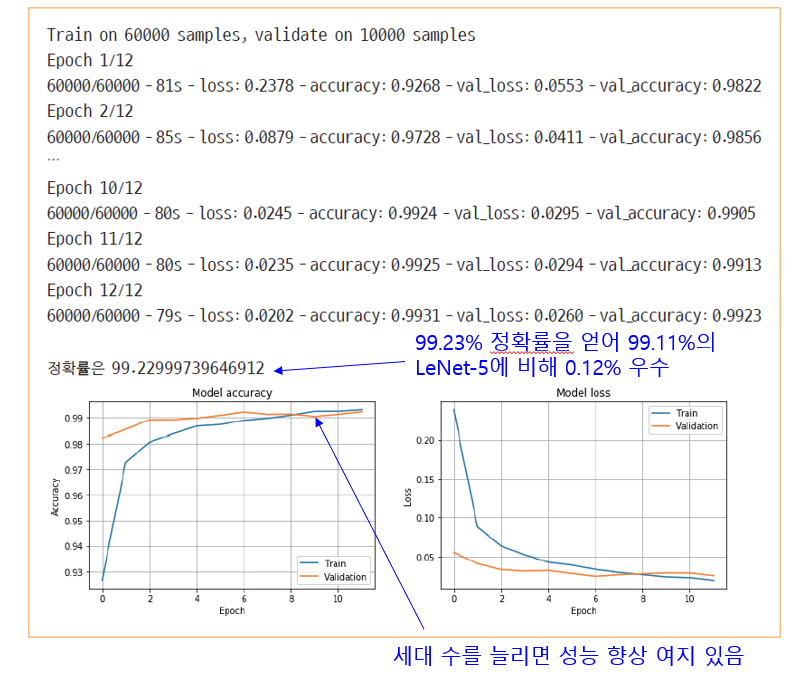

In [ ]:
# ------------------------------------------------------------
# [전체 개요]
# 본 코드는 CNN(합성곱 신경망)을 활용하여 Fashion MNIST 의류 이미지 데이터를 분류하는 모델을 설계하고 학습하는 예제임.
#
# [처리 순서]
# 1. 필요한 라이브러리 불러오기 및 데이터셋 로드
# 2. 입력 데이터 전처리 (reshape, 정규화, one-hot encoding)
# 3. CNN 모델 정의 (Conv2D, MaxPooling2D, Dropout, Dense 구성)
# 4. 모델 컴파일 및 학습 수행
# 5. 테스트 데이터셋으로 모델 성능 평가
# 6. 학습 정확률 및 손실 시각화
# ------------------------------------------------------------

import numpy as np  # 다차원 배열 및 수치 연산 처리를 위한 numpy 모듈 불러오기
import tensorflow as tf  # 딥러닝 모델 생성을 위한 TensorFlow 모듈 불러오기
from tensorflow.keras.datasets import fashion_mnist  # Fashion MNIST 데이터셋 로드를 위한 모듈 불러오기
from tensorflow.keras.models import Sequential  # 순차적 모델 구조 생성을 위한 클래스 불러오기
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout  # CNN 설계에 필요한 주요 레이어 클래스 불러오기
from tensorflow.keras.optimizers import Adam  # Adam 최적화 알고리즘 클래스 불러오기

# Fashion MNIST 데이터셋 로드 및 훈련/테스트 세트 분리
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()  # 학습용 및 평가용 데이터셋 로드 수행

# 입력 데이터를 CNN 입력 형식(28x28x1)으로 reshape 수행
x_train = x_train.reshape(60000, 28, 28, 1)  # 훈련 데이터 차원 변환 수행
x_test = x_test.reshape(10000, 28, 28, 1)  # 테스트 데이터 차원 변환 수행

# 입력 이미지 픽셀 값 정규화 (0~255 → 0~1)
x_train = x_train.astype(np.float32) / 255.0  # 훈련 데이터 정규화 수행
x_test = x_test.astype(np.float32) / 255.0  # 테스트 데이터 정규화 수행

# 정답 레이블을 one-hot encoding 형식으로 변환 (10개의 클래스 사용)
y_train = tf.keras.utils.to_categorical(y_train, 10)  # 훈련 레이블 one-hot 인코딩 처리
y_test = tf.keras.utils.to_categorical(y_test, 10)  # 테스트 레이블 one-hot 인코딩 처리

# CNN 모델 정의 시작
cnn = Sequential()  # 순차적 모델 구성 객체 생성

# 첫 번째 합성곱 계층: 32개의 3x3 필터, ReLU 활성화 함수, 입력 크기 지정
cnn.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))  # 첫 번째 Conv 레이어 추가

# 두 번째 합성곱 계층: 64개의 3x3 필터, ReLU 활성화 함수 적용
cnn.add(Conv2D(64, (3, 3), activation='relu'))  # 두 번째 Conv 레이어 추가

# 최대 풀링 계층: 2x2 필터를 이용한 공간 축소
cnn.add(MaxPooling2D(pool_size=(2, 2)))  # 공간 정보 축소를 위한 MaxPooling 레이어 삽입

# Dropout 계층: 25% 뉴런 랜덤 제거를 통한 과적합 방지 적용
cnn.add(Dropout(0.25))  # 첫 번째 Dropout 레이어 삽입

# 다차원 특징 맵을 1차원 벡터로 변환
cnn.add(Flatten())  # Flatten 연산을 통한 평탄화 수행

# 완전 연결층: 128개의 노드, ReLU 활성화 함수 적용
cnn.add(Dense(128, activation='relu'))  # 특징 벡터로부터 분류를 위한 Dense 레이어 추가

# Dropout 계층: 50% 뉴런 랜덤 제거를 통한 일반화 향상
cnn.add(Dropout(0.5))  # 두 번째 Dropout 레이어 삽입

# 출력층: 10개 클래스에 대한 확률 출력, softmax 활성화 함수 사용
cnn.add(Dense(10, activation='softmax'))  # 최종 분류 출력층 추가

# 모델 컴파일: categorical_crossentropy 손실 함수, Adam 옵티마이저, 정확률을 평가지표로 설정
cnn.compile(loss='categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])  # 모델 컴파일 작업 수행

# 모델 학습 수행: 배치 사이즈 128, 총 12 에폭, 검증 데이터로 테스트 세트 사용
hist = cnn.fit(x_train, y_train, batch_size=128, epochs=12,
               validation_data=(x_test, y_test), verbose=2)  # 모델 학습 실행

# 테스트 데이터셋을 이용한 최종 정확률 평가
res = cnn.evaluate(x_test, y_test, verbose=0)  # 모델 평가 실행
print("정확률은", res[1] * 100)  # 테스트 정확률을 백분율로 출력

import matplotlib.pyplot as plt  # 학습 결과 시각화를 위한 matplotlib 모듈 불러오기

# 정확률 변화 시각화
plt.plot(hist.history['accuracy'])  # 훈련 정확률 추이 그래프 그리기
plt.plot(hist.history['val_accuracy'])  # 검증 정확률 추이 그래프 그리기
plt.title('Model accuracy')  # 그래프 제목 설정
plt.ylabel('Accuracy')  # y축 이름 설정
plt.xlabel('Epoch')  # x축 이름 설정
plt.legend(['Train', 'Validation'], loc='best')  # 범례 설정
plt.grid()  # 격자 추가
plt.show()  # 정확률 그래프 출력

# 손실 함수 변화 시각화
plt.plot(hist.history['loss'])  # 훈련 손실 추이 그래프 그리기
plt.plot(hist.history['val_loss'])  # 검증 손실 추이 그래프 그리기
plt.title('Model loss')  # 그래프 제목 설정
plt.ylabel('Loss')  # y축 이름 설정
plt.xlabel('Epoch')  # x축 이름 설정
plt.legend(['Train', 'Validation'], loc='best')  # 범례 설정
plt.grid()  # 격자 추가
plt.show()  # 손실 함수 그래프 출력


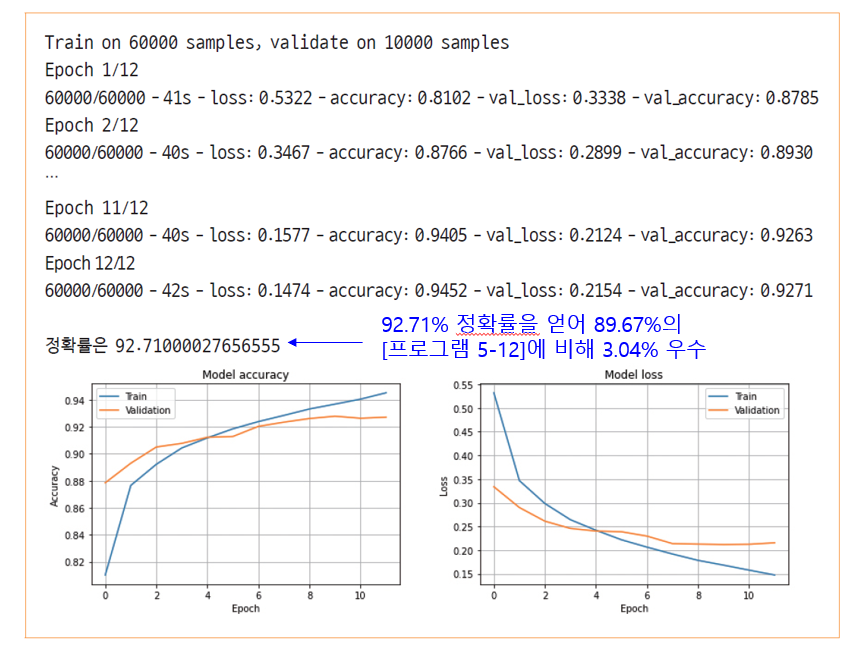

In [ ]:
# ------------------------------------------------------------
# [전체 개요]
# 본 코드는 CIFAR-10 이미지 데이터셋을 이용하여 CNN(합성곱 신경망)을 구성하고 학습시켜,
# 10개의 다양한 이미지 클래스(비행기, 자동차, 새 등)를 분류하는 모델을 구축하는 예제임.
#
# [처리 순서]
# 1. 필요한 라이브러리 및 데이터셋 로드
# 2. CIFAR-10 이미지 및 레이블 전처리 (정규화, One-hot 인코딩)
# 3. CNN 모델 설계 (Conv2D, MaxPooling2D, Dropout, Dense 포함)
# 4. 모델 컴파일 및 학습 수행
# 5. 모델 평가 및 정확률 출력
# 6. 학습 결과 시각화 (정확률, 손실 그래프)
# 7. 학습된 모델 저장
# ------------------------------------------------------------

import numpy as np  # 수치 계산을 위한 numpy 모듈 불러오기
import tensorflow as tf  # 딥러닝 프레임워크 TensorFlow 불러오기
from tensorflow.keras.datasets import cifar10  # CIFAR-10 이미지 데이터셋 로드를 위한 모듈 불러오기
from tensorflow.keras.models import Sequential  # 순차적 모델 생성을 위한 클래스 불러오기
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout  # CNN 레이어 구성에 필요한 모듈 불러오기
from tensorflow.keras.optimizers import Adam  # Adam 최적화 알고리즘 불러오기

# CIFAR-10 데이터셋 로드 및 훈련/테스트 데이터 분할
(x_train, y_train), (x_test, y_test) = cifar10.load_data()  # 이미지와 정답 데이터를 훈련/테스트 세트로 분리

# 이미지 데이터를 0~1 범위로 정규화
x_train = x_train.astype(np.float32) / 255.0  # 훈련 이미지 정규화 수행
x_test = x_test.astype(np.float32) / 255.0  # 테스트 이미지 정규화 수행

# 정답 레이블을 One-hot 인코딩 형식으로 변환
y_train = tf.keras.utils.to_categorical(y_train, 10)  # 훈련 레이블 one-hot 인코딩
y_test = tf.keras.utils.to_categorical(y_test, 10)  # 테스트 레이블 one-hot 인코딩

# CNN 모델 설계 시작
cnn = Sequential()  # 순차적으로 레이어를 쌓는 모델 객체 생성

# 첫 번째 합성곱 계층: 32개 필터, 커널 크기 3x3, ReLU 활성화 함수 사용, 입력 크기 (32x32x3)
cnn.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))  # 입력 이미지에 대한 특징 추출 수행

# 두 번째 합성곱 계층: 32개 필터, 커널 크기 3x3, ReLU 활성화 함수 사용
cnn.add(Conv2D(32, (3, 3), activation='relu'))  # 추가 특징 추출을 위한 Conv 레이어 추가

# 최대 풀링 계층: 2x2 풀링 크기
cnn.add(MaxPooling2D(pool_size=(2, 2)))  # 공간 크기 축소 및 연산 효율화 수행

# Dropout 계층: 25% 비율로 뉴런 무작위 비활성화 수행
cnn.add(Dropout(0.25))  # 과적합 방지를 위한 드롭아웃 적용

# 세 번째 합성곱 계층: 64개 필터, 커널 크기 3x3, ReLU 활성화 함수 사용
cnn.add(Conv2D(64, (3, 3), activation='relu'))  # 깊은 특징 추출 수행

# 네 번째 합성곱 계층: 64개 필터, 커널 크기 3x3, ReLU 활성화 함수 사용
cnn.add(Conv2D(64, (3, 3), activation='relu'))  # 보다 추상적인 특징 추출 수행

# 두 번째 최대 풀링 계층: 2x2 풀링
cnn.add(MaxPooling2D(pool_size=(2, 2)))  # 추가적인 공간 축소 수행

# Dropout 계층: 25% 비율로 뉴런 무작위 비활성화 수행
cnn.add(Dropout(0.25))  # 두 번째 드롭아웃 적용

# Flatten 계층: 다차원 데이터를 1차원 벡터로 변환
cnn.add(Flatten())  # Dense 계층 입력을 위한 평탄화 수행

# 완전 연결층(Dense): 512개 뉴런, ReLU 활성화 함수 사용
cnn.add(Dense(512, activation='relu'))  # 분류를 위한 고차원 특성 결합 수행

# Dropout 계층: 50% 비율로 뉴런 무작위 비활성화 수행
cnn.add(Dropout(0.5))  # 과적합 방지를 위한 드롭아웃 적용

# 출력층(Dense): 10개 클래스, softmax 활성화 함수 사용
cnn.add(Dense(10, activation='softmax'))  # 클래스별 확률 출력을 위한 출력층 설정

# 모델 컴파일: 손실 함수 categorical_crossentropy, 최적화 알고리즘 Adam, 평가 지표 accuracy 사용
cnn.compile(loss='categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])  # 학습 설정 수행

# 모델 학습 수행: 배치 크기 128, 에폭 수 30, 검증 데이터로 테스트 세트 지정
hist = cnn.fit(x_train, y_train, batch_size=128, epochs=30,
               validation_data=(x_test, y_test), verbose=2)  # 모델 학습 및 검증 수행

# 테스트 데이터셋을 통한 모델 성능 평가
res = cnn.evaluate(x_test, y_test, verbose=0)  # 테스트 데이터로 모델 성능 평가
print("정확률은", res[1] * 100)  # 정확률을 백분율로 출력

import matplotlib.pyplot as plt  # 시각화를 위한 matplotlib 모듈 불러오기

# 학습 정확률 및 검증 정확률 그래프 시각화
plt.plot(hist.history['accuracy'])  # 훈련 정확률 추이 플롯
plt.plot(hist.history['val_accuracy'])  # 검증 정확률 추이 플롯
plt.title('Model accuracy')  # 그래프 제목 설정
plt.ylabel('Accuracy')  # y축 레이블 설정
plt.xlabel('Epoch')  # x축 레이블 설정
plt.legend(['Train', 'Validation'], loc='best')  # 범례 설정
plt.grid()  # 격자 표시
plt.show()  # 정확률 그래프 출력

# 학습 손실 및 검증 손실 그래프 시각화
plt.plot(hist.history['loss'])  # 훈련 손실 추이 플롯
plt.plot(hist.history['val_loss'])  # 검증 손실 추이 플롯
plt.title('Model loss')  # 그래프 제목 설정
plt.ylabel('Loss')  # y축 레이블 설정
plt.xlabel('Epoch')  # x축 레이블 설정
plt.legend(['Train', 'Validation'], loc='best')  # 범례 설정
plt.grid()  # 격자 표시
plt.show()  # 손실 그래프 출력

# 학습 완료된 CNN 모델 저장
cnn.save("my_cnn.h5")  # 모델 구조와 가중치를 파일로 저장


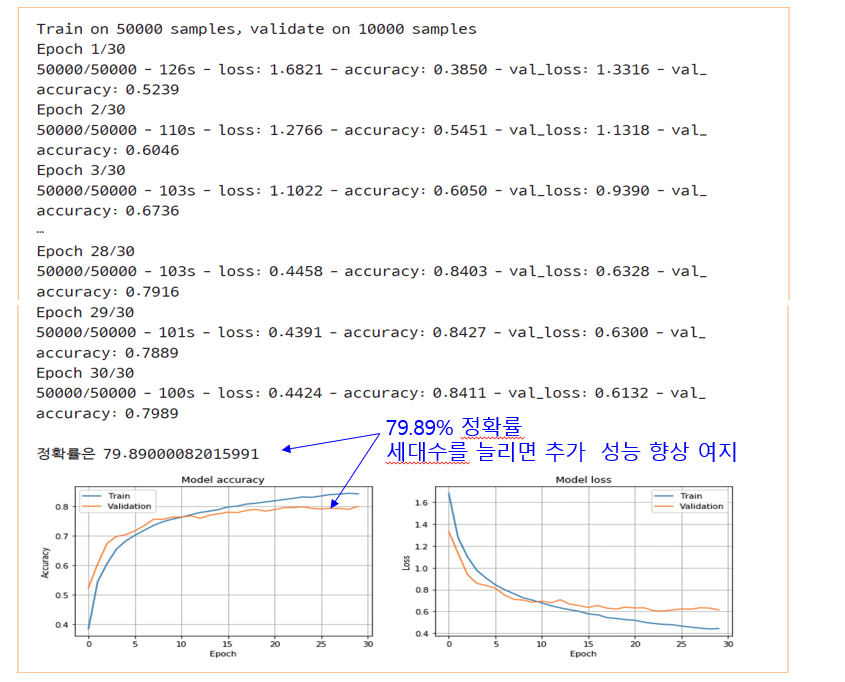

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

# 신경망 구조와 가중치를 저장하고 있는 파일을 읽어 옴
# 코랩 사용 예 : "./drive/MyDrive/AI_2025_1st/my_cnn.h5"

cnn=tf.keras.models.load_model("my_cnn.h5")
cnn.summary()

# CIFAR-10 데이터셋을 읽고 신경망에 입력할 형태로 변환
(x_train,y_train),(x_test,y_test)=cifar10.load_data()
x_train=x_train.astype(np.float32)/255.0
x_test=x_test.astype(np.float32)/255.0
y_train=tf.keras.utils.to_categorical(y_train,10)
y_test=tf.keras.utils.to_categorical(y_test,10)

res=cnn.evaluate(x_test,y_test,verbose=0)
print("정확률은",res[1]*100)

In [ ]:
# ------------------------------------------------------------
# [전체 개요]
# 본 코드는 학습이 완료된 CNN 모델 파일(`my_cnn.h5`)을 불러와 CIFAR-10 데이터셋에 대해 성능을 평가하는 과정으로 구성됨.
#
# [처리 순서]
# 1. 필요한 라이브러리 및 CIFAR-10 데이터셋 로드
# 2. 저장된 모델 파일(my_cnn.h5) 불러오기 및 구조 출력
# 3. CIFAR-10 데이터셋 전처리 (정규화, One-hot 인코딩)
# 4. 테스트 데이터셋을 이용한 정확률 평가 및 출력
# ------------------------------------------------------------

import numpy as np  # 다차원 배열 및 수치 계산을 위한 numpy 모듈 불러오기
import tensorflow as tf  # 딥러닝 모델 구동 및 데이터 전처리를 위한 TensorFlow 모듈 불러오기
from tensorflow.keras.datasets import cifar10  # CIFAR-10 데이터셋 로드 모듈 불러오기

# 학습된 CNN 모델(.h5 파일) 불러오기
# ※ 코랩 사용 시: 경로를 예시처럼 "/content/drive/MyDrive/..." 형식으로 지정 필요
cnn = tf.keras.models.load_model("my_cnn.h5")  # 저장된 신경망 구조 및 가중치 로드

# 모델 구조 요약 출력
cnn.summary()  # 모델의 레이어 구성, 파라미터 수, 출력 형상 등을 요약 출력

# CIFAR-10 데이터셋 로드 및 훈련/테스트 데이터 분리
(x_train, y_train), (x_test, y_test) = cifar10.load_data()  # CIFAR-10 데이터셋 다운로드 및 분할

# 입력 이미지 정규화 (픽셀 범위 0~255 → 0~1)
x_train = x_train.astype(np.float32) / 255.0  # 훈련 이미지 정규화 처리
x_test = x_test.astype(np.float32) / 255.0  # 테스트 이미지 정규화 처리

# 정답 레이블을 One-hot 인코딩 형식으로 변환 (총 클래스 수: 10개)
y_train = tf.keras.utils.to_categorical(y_train, 10)  # 훈련 정답 벡터 변환
y_test = tf.keras.utils.to_categorical(y_test, 10)  # 테스트 정답 벡터 변환

# 테스트 데이터셋을 이용한 모델 평가 수행
res = cnn.evaluate(x_test, y_test, verbose=0)  # 손실값 및 정확률 평가 수행

# 정확률 출력 (소수점 두 자리까지 백분율 형식으로 출력)
print("정확률은", res[1] * 100)  # 테스트 데이터에 대한 분류 정확률 출력


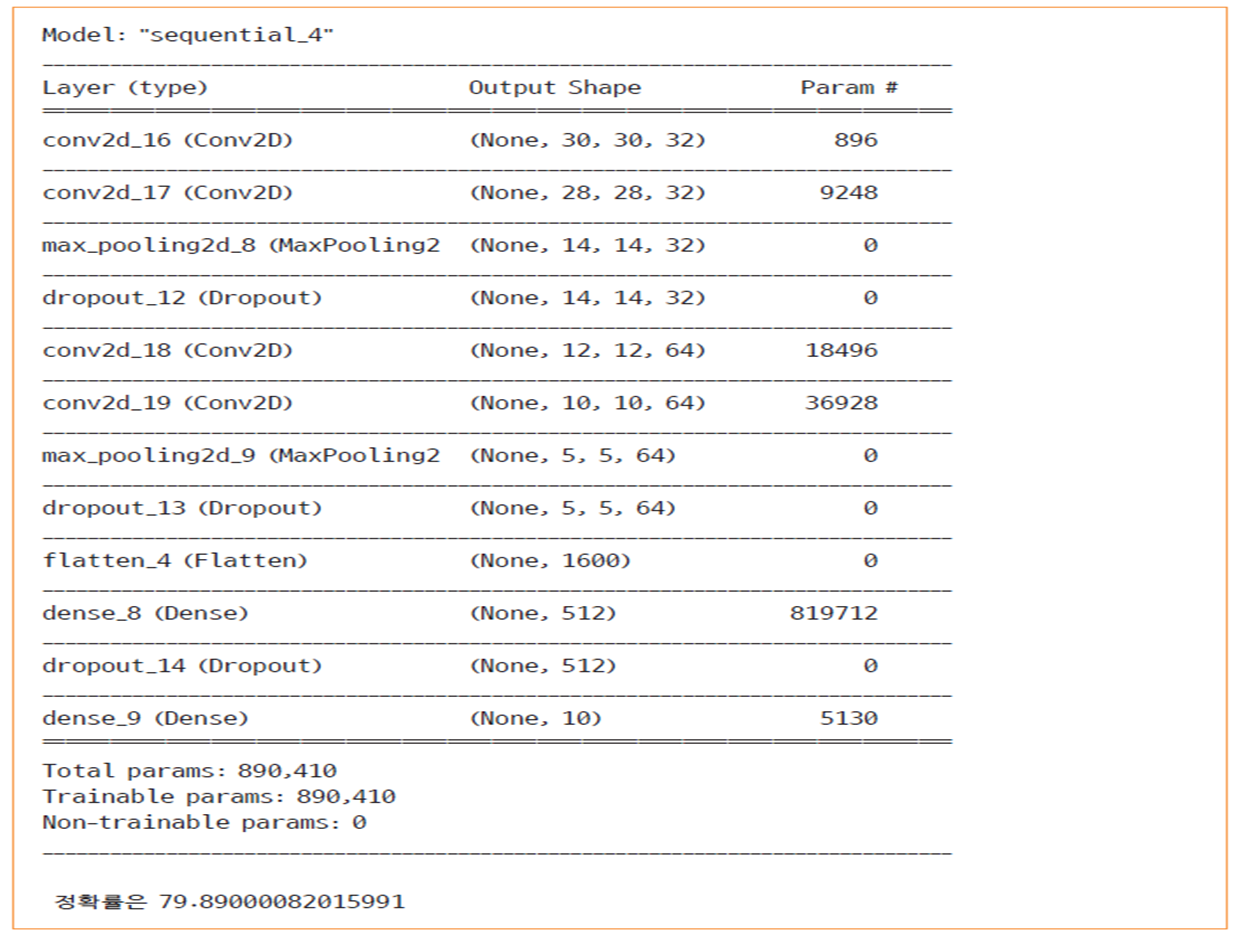

In [ ]:
# ------------------------------------------------------------
# [전체 개요]
# 본 코드는 CIFAR-10 데이터셋을 기반으로 CNN을 학습시킨 후,
# 모델 내부의 합성곱 계층에서 학습된 커널(필터)과 특징 맵(feature map)을 시각화함으로써
# CNN이 어떤 방식으로 이미지를 해석하는지 시각적으로 분석하는 코드임.
#
# [세부 처리 흐름]
# 1. CIFAR-10 데이터셋 로드 및 전처리 (정규화, one-hot 인코딩)
# 2. CNN 모델 구성 및 학습
# 3. 합성곱 계층별 커널 구조 확인 및 시각화
# 4. 모델 일부 계층만을 사용하는 부분 모델 구성
# 5. 특징 맵(feature map) 추출 및 시각화
# ------------------------------------------------------------

import numpy as np  # 다차원 수치 연산과 배열 처리를 위한 numpy 라이브러리 임포트
import tensorflow as tf  # 딥러닝 모델 구성 및 학습을 위한 TensorFlow 프레임워크 임포트
from tensorflow.keras.datasets import cifar10  # CIFAR-10 이미지 데이터셋 로드를 위한 모듈 임포트
from tensorflow.keras.models import Sequential  # 순차적으로 레이어를 구성할 수 있는 Sequential 모델 클래스 임포트
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout  # CNN 구현을 위한 주요 레이어 클래스들 임포트
from tensorflow.keras.optimizers import Adam  # 가중치 최적화를 위한 Adam 옵티마이저 클래스 임포트

# CIFAR-10 이미지와 정답 레이블 데이터를 훈련 세트와 테스트 세트로 분할하여 로드
(x_train, y_train), (x_test, y_test) = cifar10.load_data()  # 총 60,000장의 32x32x3 이미지와 정답 레이블 반환

# 입력 이미지 데이터를 실수형으로 변환한 뒤, 0~1 사이로 정규화하여 모델 학습 안정성 향상
x_train = x_train.astype(np.float32) / 255.0  # 훈련 이미지 데이터 정규화 처리
x_test = x_test.astype(np.float32) / 255.0  # 테스트 이미지 데이터 정규화 처리

# 정답 레이블을 다중 클래스 분류에 적합한 one-hot 인코딩 형식으로 변환
y_train = tf.keras.utils.to_categorical(y_train, 10)  # 훈련 레이블의 범주형 변환 수행 (10개의 클래스)
y_test = tf.keras.utils.to_categorical(y_test, 10)  # 테스트 레이블의 범주형 변환 수행

# CNN 모델 구성 시작
cnn = Sequential()  # 레이어를 순차적으로 쌓기 위한 모델 객체 생성

# 첫 번째 합성곱 계층: 32개의 3x3 필터, ReLU 활성화 함수 사용, 입력 크기는 32x32x3으로 지정
cnn.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))  # 저수준 특징 추출을 위한 첫 번째 Conv 레이어 추가

# 두 번째 합성곱 계층: 동일한 필터 수와 커널 크기를 사용하여 더 복잡한 특징 추출 수행
cnn.add(Conv2D(32, (3, 3), activation='relu'))  # 첫 번째 계층의 특징맵을 기반으로 고차원 특징 추출

# 첫 번째 최대 풀링 계층: 2x2 윈도우 크기를 사용하여 공간 차원을 절반으로 축소
cnn.add(MaxPooling2D(pool_size=(2, 2)))  # 지역적 특징 중 중요한 값을 유지하면서 크기 감소

# 드롭아웃 계층: 학습 시 25%의 뉴런을 무작위로 비활성화하여 과적합 방지
cnn.add(Dropout(0.25))  # 모델의 일반화 성능을 높이기 위한 정규화 기법 적용

# 세 번째 합성곱 계층: 필터 수를 64개로 증가시켜 더 풍부한 표현 학습 수행
cnn.add(Conv2D(64, (3, 3), activation='relu'))  # 고수준 특징 추출을 위한 Conv 레이어 추가

# 네 번째 합성곱 계층: 동일한 설정으로 한 번 더 특징을 추출하여 정보 표현 강화
cnn.add(Conv2D(64, (3, 3), activation='relu'))  # 계층적 특징 표현력 강화

# 두 번째 최대 풀링 계층: 이전과 동일하게 2x2 윈도우를 사용하여 다운샘플링 수행
cnn.add(MaxPooling2D(pool_size=(2, 2)))  # 높은 추상화 수준의 특징에 대해서도 공간 축소 적용

# 추가 드롭아웃 계층: 뉴런의 25% 비활성화 수행
cnn.add(Dropout(0.25))  # 두 번째 정규화 계층을 통한 과적합 억제

# Flatten 계층: 다차원 특징맵을 1차원 벡터로 변환하여 Dense 계층에 입력
cnn.add(Flatten())  # 완전 연결층(Dense)의 입력 형식으로 변환

# 첫 번째 완전 연결층: 뉴런 수 512개, ReLU 활성화 함수 사용
cnn.add(Dense(512, activation='relu'))  # 고차원 표현 학습 및 최종 분류를 위한 특징 통합 수행

# 세 번째 드롭아웃 계층: 학습 중 50%의 뉴런 비활성화
cnn.add(Dropout(0.5))  # 더욱 강력한 정규화를 통한 일반화 성능 확보

# 출력층: 클래스 수 10개, softmax 함수 사용으로 다중 클래스 확률 출력
cnn.add(Dense(10, activation='softmax'))  # 클래스별 예측 확률 출력

# 모델 컴파일: categorical_crossentropy 손실 함수, Adam 옵티마이저, 정확률을 평가지표로 사용
cnn.compile(loss='categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])  # 모델 학습 준비 설정

# CNN 모델 학습 실행: 배치 사이즈 128, 에폭 수 30, 검증 데이터는 테스트셋 사용
hist = cnn.fit(x_train, y_train, batch_size=128, epochs=30,
               validation_data=(x_test, y_test), verbose=2)  # 모델 학습 및 검증 수행

# 모델 구조 요약 출력: 레이어별 파라미터 수, 출력 형태 확인
cnn.summary()

# 각 레이어 중 합성곱 계층에 대해 커널의 형상을 출력
for layer in cnn.layers:
    if 'conv' in layer.name:  # 레이어 이름에 'conv'가 포함되어 있는 경우
        kernel, biases = layer.get_weights()  # 해당 레이어의 커널과 바이어스 가중치 추출
        print(layer.name, kernel.shape)  # 커널 텐서의 모양 출력

# 첫 번째 합성곱 계층의 커널 값을 정규화하여 시각화 준비
kernel, biases = cnn.layers[0].get_weights()  # 0번째 합성곱 계층의 커널 추출
minv, maxv = kernel.min(), kernel.max()  # 커널의 최소 및 최대값 추출
kernel = (kernel - minv) / (maxv - minv)  # 시각화를 위한 0~1 정규화 수행
n_kernel = 32  # 총 시각화할 커널 수 설정

import matplotlib.pyplot as plt  # 시각화를 위한 matplotlib.pyplot 임포트

# 첫 번째 합성곱 계층의 커널을 각 RGB 채널별로 시각화
plt.figure(figsize=(20, 3))  # 전체 도화지 크기 설정
plt.suptitle("Kernels of conv2d_4")  # 전체 시각화 제목 출력
for i in range(n_kernel):  # 각 필터별로 반복
    f = kernel[:, :, :, i]  # i번째 필터에 해당하는 3차원 커널 추출
    for j in range(3):  # RGB 채널별 반복
        plt.subplot(3, n_kernel, j * n_kernel + i + 1)  # 서브플롯 위치 지정
        plt.imshow(f[:, :, j], cmap='gray')  # 커널 시각화
        plt.xticks([]); plt.yticks([])  # 축 눈금 제거
        plt.title(str(i) + '_' + str(j))  # 커널 번호와 채널 번호 출력
plt.show()  # 최종 시각화 결과 출력

# 합성곱 계층들의 출력 텐서 형태(특징맵 형상) 출력
for layer in cnn.layers:
    if 'conv' in layer.name:
        print(layer.name, layer.output.shape)

from tensorflow.keras.models import Model  # 부분 모델 생성을 위한 Model 클래스 임포트

# 첫 번째 합성곱 계층까지의 출력을 반환하는 부분 모델 생성
partial_model = Model(inputs=cnn.inputs, outputs=cnn.layers[0].output)
partial_model.summary()  # 부분 모델 구조 요약 출력

# 부분 모델로 테스트 세트 이미지를 예측하여 특징 맵 추출
feature_map = partial_model.predict(x_test)  # 특징 맵 예측 결과 저장
fm = feature_map[1]  # 테스트 이미지 중 인덱스 1번 샘플의 특징 맵 추출

plt.imshow(x_test[1])  # 인덱스 1번 원본 테스트 이미지 출력

# 해당 이미지의 특징 맵을 32개 모두 시각화
plt.figure(figsize=(20, 3))  # 도화지 크기 설정
plt.suptitle("Feature maps of conv2d_4")  # 제목 설정
for i in range(32):  # 32개의 출력 채널에 대해 반복
    plt.subplot(2, 16, i + 1)  # 2행 16열의 서브플롯 생성
    plt.imshow(fm[:, :, i], cmap='gray')  # i번째 특징 맵 시각화
    plt.xticks([]); plt.yticks([])  # 눈금 제거
    plt.title("map" + str(i))  # 특징 맵 번호 출력
plt.show()  # 전체 시각화 출력


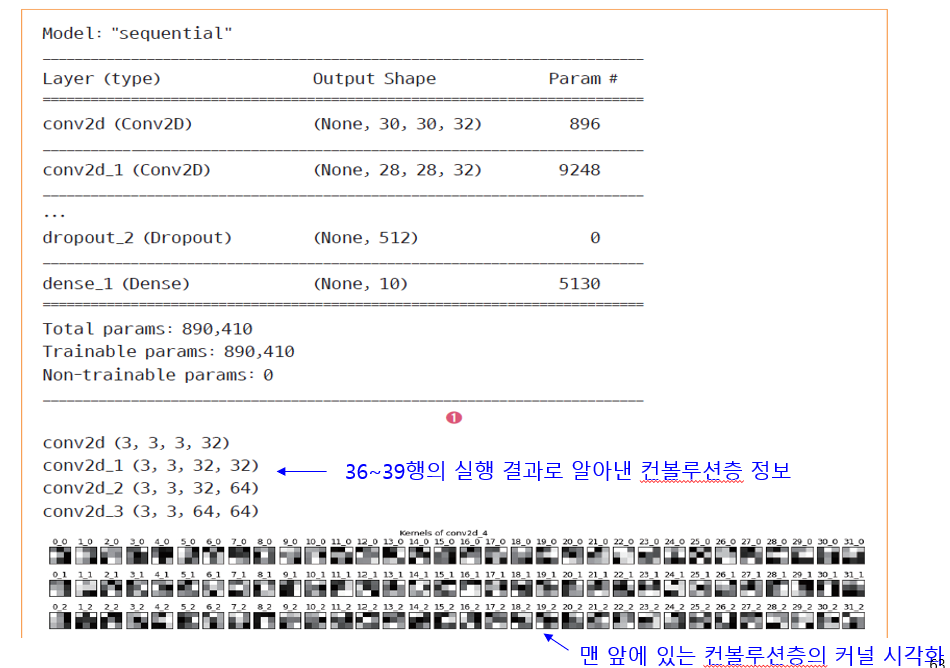

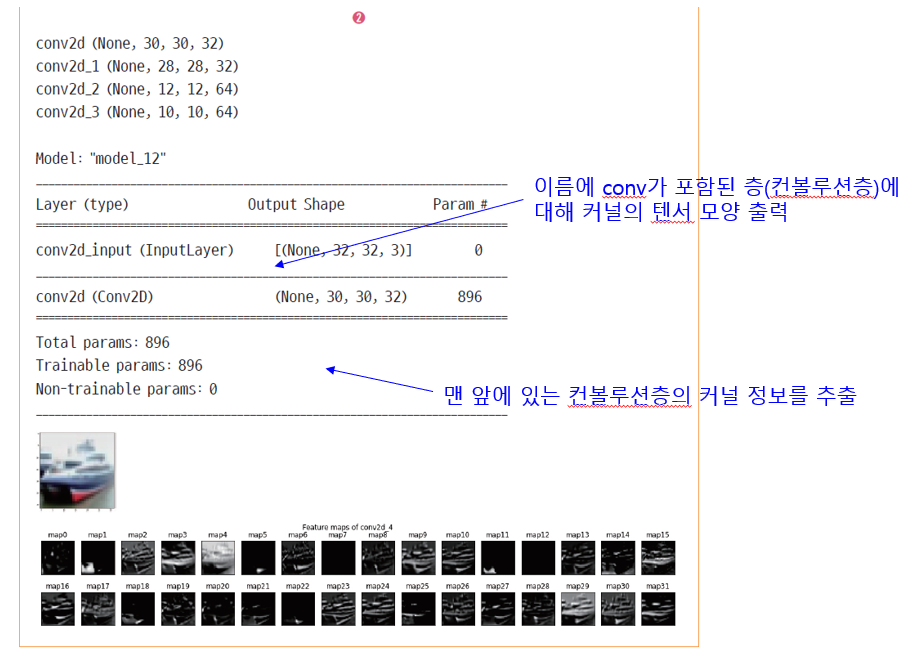

In [ ]:
# ------------------------------------------------------------
# [전체 개요]
# 본 코드는 TensorFlow의 ImageDataGenerator를 활용하여 CIFAR-10 이미지 데이터에 대한
# 데이터 증강(Data Augmentation)을 수행하고, 증강된 이미지들을 시각적으로 확인하는 예제임.
#
# [처리 흐름]
# 1. CIFAR-10 데이터셋 로드 및 전처리 (정규화, 12개 샘플 추출)
# 2. 추출한 원본 샘플 이미지 시각화
# 3. ImageDataGenerator 객체를 통한 회전·이동·좌우반전 증강 설정
# 4. 생성기(generator)로부터 두 배치의 증강된 이미지 생성
# 5. 생성된 이미지 각각을 시각화하여 증강 효과 확인
# ------------------------------------------------------------

from tensorflow.keras.datasets import cifar10  # CIFAR-10 데이터셋 로드를 위한 모듈 임포트
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # 이미지 데이터 증강을 위한 유틸리티 클래스 임포트
import matplotlib.pyplot as plt  # 이미지 시각화를 위한 matplotlib 라이브러리 임포트

# CIFAR-10의 각 클래스에 대응하는 클래스 이름 정의
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'flog', 'horse', 'ship', 'truck']  # 총 10개 부류 이름 설정

# CIFAR-10 데이터셋 로드 및 훈련/테스트 세트 분리
(x_train, y_train), (x_test, y_test) = cifar10.load_data()  # 총 50,000개의 훈련 이미지와 10,000개의 테스트 이미지 로드

# 훈련 이미지를 float32 형식으로 변환한 후, 픽셀 값 범위를 [0, 1]로 정규화
x_train = x_train.astype('float32'); x_train /= 255.0  # 학습 안정성을 위한 정규화 수행

# 데이터 증강의 대상이 될 앞쪽 12개 이미지 및 레이블만 추출
x_train = x_train[0:12, :]  # 첫 12개 샘플 이미지 선택
y_train = y_train[0:12, :]  # 첫 12개 샘플 정답 레이블 선택

# 원본 12개 이미지 시각화
plt.figure(figsize=(16, 2))  # 가로 16, 세로 2 크기의 출력창 설정
plt.suptitle("First 12 images in the train set")  # 전체 그래프 제목 설정
for i in range(12):  # 0~11번까지 반복하여 이미지 출력
    plt.subplot(1, 12, i + 1)  # 1행 12열의 서브플롯 중 i+1번째 위치 지정
    plt.imshow(x_train[i])  # i번째 이미지를 출력
    plt.xticks([]); plt.yticks([])  # 축 눈금 제거
    plt.title(class_names[int(y_train[i])])  # 해당 이미지의 클래스 이름을 타이틀로 표시

# 이미지 증강기(ImageDataGenerator) 객체 생성
generator = ImageDataGenerator(
    rotation_range=30.0,         # -30도 ~ +30도 범위에서 무작위 회전 적용
    width_shift_range=0.2,       # 가로 방향으로 최대 20% 무작위 이동 적용
    height_shift_range=0.2,      # 세로 방향으로 최대 20% 무작위 이동 적용
    horizontal_flip=True         # 좌우 반전 활성화
)

batch_siz = 6  # 한 번에 생성할 증강 샘플 수 설정
gen = generator.flow(x_train, y_train, batch_size=batch_siz)  # 실시간 증강 이미지 생성기 정의

# 첫 번째 증강 샘플 배치 생성 및 시각화
img, label = next(gen)  # 첫 번째 증강 배치를 생성 (이미지와 레이블 반환)
plt.figure(figsize=(16, 3))  # 가로 16, 세로 3 크기의 출력창 설정
plt.suptitle("Generator trial 1")  # 전체 그래프 제목 설정
for i in range(batch_siz):  # 배치 크기만큼 반복 출력
    plt.subplot(1, batch_siz, i + 1)  # 1행 n열의 서브플롯 구성
    plt.imshow(img[i])  # 증강된 i번째 이미지 출력
    plt.xticks([]); plt.yticks([])  # 축 눈금 제거
    plt.title(class_names[int(label[i])])  # 증강된 이미지의 레이블 클래스 표시

# 두 번째 증강 샘플 배치 생성 및 시각화
img, label = next(gen)  # 두 번째 증강 배치를 생성
plt.figure(figsize=(16, 3))  # 새로운 출력창 설정
plt.suptitle("Generator trial 2")  # 두 번째 시각화 제목 설정
for i in range(batch_siz):  # 두 번째 배치의 이미지 출력
    plt.subplot(1, batch_siz, i + 1)
    plt.imshow(img[i])
    plt.xticks([]); plt.yticks([])
    plt.title(class_names[int(label[i])])
plt.show()  # 시각화된 이미지 전체 출력


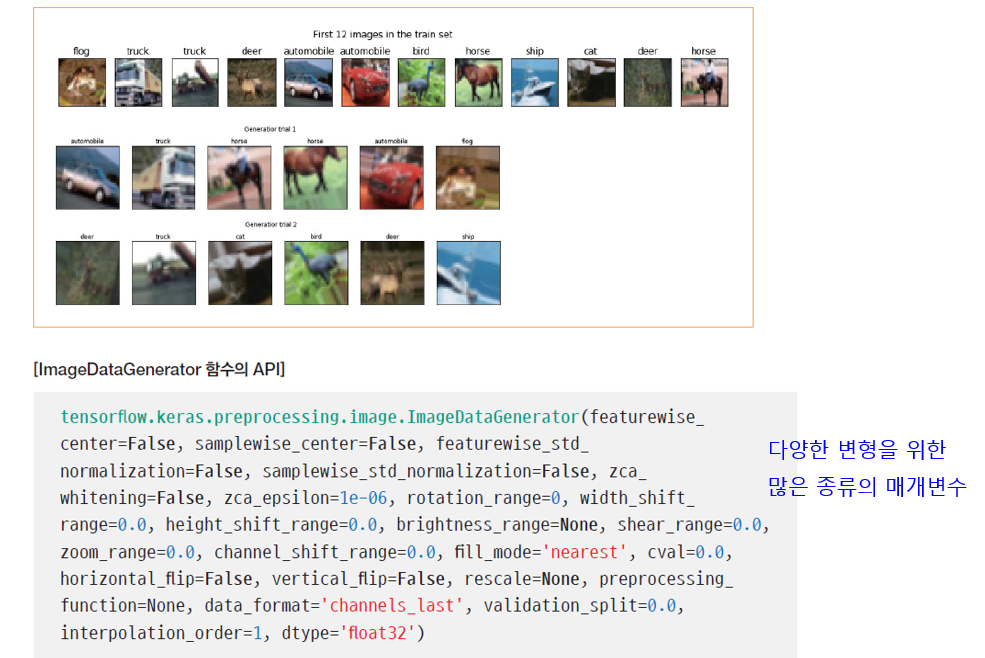

In [ ]:
# ------------------------------------------------------------
# [전체 개요]
# 본 코드는 CIFAR-10 이미지 분류를 위한 CNN 모델을 구성하고,
# 모델 학습 과정에서 ImageDataGenerator를 사용하여 실시간 데이터 증강을 적용함으로써
# 모델의 일반화 성능을 높이는 과정을 포함함.
#
# [처리 흐름]
# 1. CIFAR-10 데이터셋 로드 및 전처리
# 2. CNN 아키텍처 구성
# 3. ImageDataGenerator를 통한 학습용 데이터 증강
# 4. 증강된 데이터를 기반으로 모델 학습 수행
# 5. 학습 완료 후 테스트셋 정확률 평가 및 시각화
# ------------------------------------------------------------

import numpy as np  # 배열 연산 및 수치 계산을 위한 numpy 모듈 임포트
import tensorflow as tf  # 딥러닝 모델 구성 및 학습을 위한 TensorFlow 프레임워크 임포트
from tensorflow.keras.datasets import cifar10  # CIFAR-10 데이터셋 로드를 위한 모듈 임포트
from tensorflow.keras.models import Sequential  # 순차적 모델 구성을 위한 클래스 임포트
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout  # CNN 구현에 필요한 주요 레이어 클래스 임포트
from tensorflow.keras.optimizers import Adam  # 가중치 최적화를 위한 Adam 옵티마이저 클래스 임포트
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # 실시간 이미지 증강을 위한 클래스 임포트

# CIFAR-10 데이터셋 로드 및 훈련/테스트 데이터 분리
(x_train, y_train), (x_test, y_test) = cifar10.load_data()  # 총 60,000장의 32x32x3 이미지와 정답 레이블 반환

# 입력 이미지 데이터를 실수형으로 변환한 뒤, 0~1 범위로 정규화하여 모델 학습 안정성 확보
x_train = x_train.astype(np.float32) / 255.0  # 훈련 이미지 정규화 수행
x_test = x_test.astype(np.float32) / 255.0  # 테스트 이미지 정규화 수행

# 정답 레이블을 다중 클래스 분류에 적합한 one-hot 인코딩 형식으로 변환
y_train = tf.keras.utils.to_categorical(y_train, 10)  # 훈련 레이블을 one-hot 벡터로 변환
y_test = tf.keras.utils.to_categorical(y_test, 10)  # 테스트 레이블을 one-hot 벡터로 변환

# CNN 모델 구성 시작
cnn = Sequential()  # 순차적으로 레이어를 쌓는 모델 객체 생성

# 첫 번째 합성곱 계층: 32개의 3x3 필터, ReLU 활성화 함수, 입력 크기 지정
cnn.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))  # 입력 이미지로부터 저수준 특징 추출

# 두 번째 합성곱 계층: 동일한 설정으로 추가 특징 추출 수행
cnn.add(Conv2D(32, (3, 3), activation='relu'))  # 첫 계층 출력에 대한 고차원 특징 추출

# 첫 번째 최대 풀링 계층: 2x2 윈도우로 공간 차원 축소
cnn.add(MaxPooling2D(pool_size=(2, 2)))  # 지역적 중요 정보 유지하면서 크기 축소

# 첫 번째 드롭아웃 계층: 학습 시 25% 뉴런 무작위 비활성화 수행
cnn.add(Dropout(0.25))  # 과적합 방지를 위한 정규화 기법 적용

# 세 번째, 네 번째 합성곱 계층: 필터 수 64개로 증가하여 고차원 특징 추출
cnn.add(Conv2D(64, (3, 3), activation='relu'))  # 더욱 복잡한 패턴 학습
cnn.add(Conv2D(64, (3, 3), activation='relu'))  # 깊은 계층에서 추상화된 정보 학습

# 두 번째 최대 풀링 계층 및 드롭아웃 적용
cnn.add(MaxPooling2D(pool_size=(2, 2)))  # 두 번째 풀링을 통해 차원 축소
cnn.add(Dropout(0.25))  # 추가 정규화 적용

# Flatten 계층: 다차원 특징맵을 1차원 벡터로 변환
cnn.add(Flatten())  # 완전 연결층 입력 형식으로 변환

# 완전 연결층: 512개 뉴런, ReLU 활성화 함수 사용
cnn.add(Dense(512, activation='relu'))  # 특징 통합을 통해 분류기 입력 생성

# 추가 드롭아웃 계층: 과적합 방지를 위한 뉴런 50% 비활성화
cnn.add(Dropout(0.5))  # 최종 정규화 처리

# 출력층: 클래스 수 10개, softmax 함수 사용
cnn.add(Dense(10, activation='softmax'))  # 다중 클래스 확률 출력

# 모델 컴파일: 손실 함수 categorical_crossentropy, 최적화 알고리즘 Adam, 평가지표 accuracy 설정
cnn.compile(loss='categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])  # 학습 준비 완료

# 이미지 증강을 위한 ImageDataGenerator 생성
generator = ImageDataGenerator(
    width_shift_range=0.1,        # 가로 방향으로 최대 10% 무작위 이동
    height_shift_range=0.1,       # 세로 방향으로 최대 10% 무작위 이동
    horizontal_flip=True          # 좌우 반전 활성화
)

batch_siz = 128  # 배치 크기 설정

# 모델 학습 실행: 데이터 증강 생성기를 사용하여 학습 세트 증강, 총 50 에폭 동안 학습 수행
hist = cnn.fit(
    generator.flow(x_train, y_train, batch_size=batch_siz),  # 실시간 증강된 이미지 생성기를 통한 학습
    epochs=50,                                               # 학습 반복 횟수 설정
    validation_data=(x_test, y_test),                        # 검증은 원본 테스트셋으로 수행
    verbose=2                                                # 학습 로그 출력 설정
)

# 테스트 데이터셋을 이용한 모델 최종 성능 평가 수행
res = cnn.evaluate(x_test, y_test, verbose=0)  # 테스트셋에 대한 손실과 정확률 계산
print("정확률은", res[1] * 100)  # 정확률을 백분율로 출력

import matplotlib.pyplot as plt  # 학습 결과 시각화를 위한 matplotlib 임포트

# 학습 정확률 및 검증 정확률 시각화
plt.plot(hist.history['accuracy'])  # 훈련 정확률 그래프
plt.plot(hist.history['val_accuracy'])  # 검증 정확률 그래프
plt.title('Model accuracy')  # 그래프 제목 설정
plt.ylabel('Accuracy')  # y축 라벨
plt.xlabel('Epoch')  # x축 라벨
plt.legend(['Train', 'Validation'], loc='best')  # 범례 설정
plt.grid()  # 격자 표시
plt.show()  # 정확률 그래프 출력

# 학습 손실 및 검증 손실 시각화
plt.plot(hist.history['loss'])  # 훈련 손실 그래프
plt.plot(hist.history['val_loss'])  # 검증 손실 그래프
plt.title('Model loss')  # 그래프 제목 설정
plt.ylabel('Loss')  # y축 라벨
plt.xlabel('Epoch')  # x축 라벨
plt.legend(['Train', 'Validation'], loc='best')  # 범례 설정
plt.grid()  # 격자 표시
plt.show()  # 손실 그래프 출력


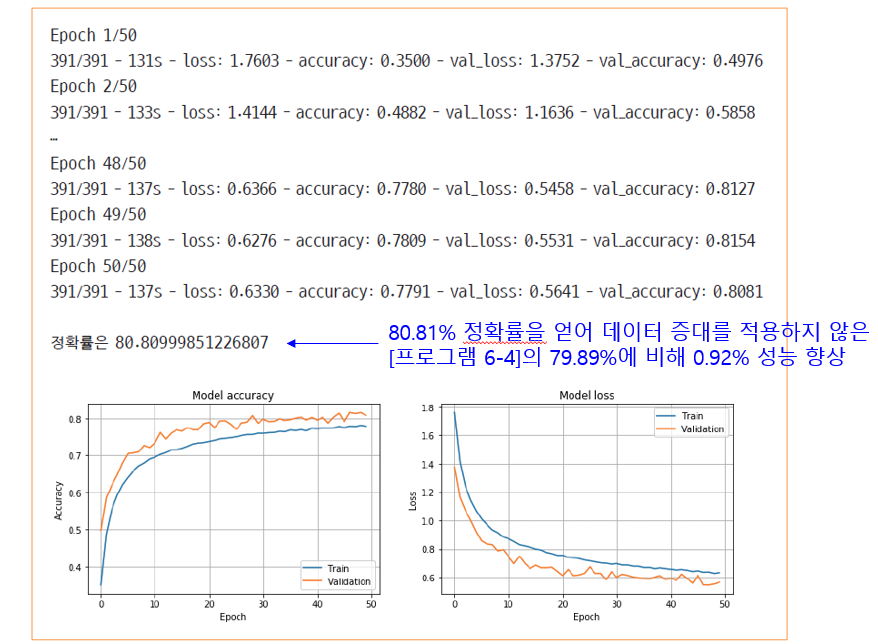

In [ ]:
# ------------------------------------------------------------
# [전체 개요]
# 본 코드는 CIFAR-10 이미지 분류를 위한 CNN 모델에 대해
# 드롭아웃(dropout) 유무에 따른 일반화 성능 차이를 평가하기 위해
# K겹 교차 검증(K-Fold Cross Validation)을 적용하고,
# 드롭아웃 적용 전후의 정확률 분포를 박스 플롯으로 시각화하는 예제임.
#
# [주요 처리 흐름]
# 1. CIFAR-10 데이터셋 로드 및 전처리
# 2. 드롭아웃 비율에 따른 교차 검증 함수 정의
# 3. 드롭아웃 유무에 따라 모델 평가 결과 비교
# 4. 박스 플롯을 통한 정확률 분포 시각화
# ------------------------------------------------------------

import numpy as np  # 다차원 배열 및 수치 계산을 위한 numpy 모듈 임포트
import tensorflow as tf  # 딥러닝 구현을 위한 TensorFlow 프레임워크 임포트
from tensorflow.keras.datasets import cifar10  # CIFAR-10 데이터셋 로드를 위한 모듈 임포트
from tensorflow.keras.models import Sequential  # 순차적 모델 구성을 위한 클래스 임포트
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout  # CNN 구성 레이어 임포트
from tensorflow.keras.optimizers import Adam  # Adam 옵티마이저 클래스 임포트
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # (사용 안함) 이미지 증강 모듈
from sklearn.model_selection import KFold  # K겹 교차 검증을 위한 KFold 클래스 임포트

# CIFAR-10 데이터셋 로드 및 훈련/테스트 세트 분리
(x_train, y_train), (x_test, y_test) = cifar10.load_data()  # 50,000개 훈련 이미지와 10,000개 테스트 이미지 로드

# 입력 이미지를 float32 타입으로 변환하고 0~1 범위로 정규화
x_train = x_train.astype(np.float32) / 255.0  # 훈련 이미지 정규화 수행
x_test = x_test.astype(np.float32) / 255.0  # 테스트 이미지 정규화 수행

# 정답 레이블을 다중 클래스 분류에 적합하도록 one-hot 인코딩
y_train = tf.keras.utils.to_categorical(y_train, 10)  # 훈련 레이블 변환
y_test = tf.keras.utils.to_categorical(y_test, 10)  # 테스트 레이블 변환

# 하이퍼파라미터 설정
batch_siz = 128  # 배치 크기 설정
n_epoch = 10  # 에폭 수 설정
k = 5  # K겹 교차 검증을 위한 fold 수 설정

# ------------------------------------------------------------
# 드롭아웃 비율을 인자로 받아 K겹 교차 검증을 수행하고 fold별 정확률을 반환하는 함수 정의
# ------------------------------------------------------------
def cross_validation(dropout_rate):
    accuracy = []  # 정확률 저장 리스트 초기화
    for train_index, val_index in KFold(k).split(x_train):  # KFold 객체를 통한 인덱스 분할 수행
        # 훈련/검증 세트를 인덱스 기준으로 분리
        xtrain, xval = x_train[train_index], x_train[val_index]  # 이미지 데이터 분할
        ytrain, yval = y_train[train_index], y_train[val_index]  # 레이블 데이터 분할

        # CNN 모델 구성
        cnn = Sequential()
        cnn.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))  # 첫 번째 Conv 레이어
        cnn.add(Conv2D(32, (3, 3), activation='relu'))  # 두 번째 Conv 레이어
        cnn.add(MaxPooling2D(pool_size=(2, 2)))  # 첫 번째 풀링 레이어
        cnn.add(Dropout(dropout_rate[0]))  # 첫 번째 드롭아웃 (입력된 비율 적용)

        cnn.add(Conv2D(64, (3, 3), activation='relu'))  # 세 번째 Conv 레이어
        cnn.add(Conv2D(64, (3, 3), activation='relu'))  # 네 번째 Conv 레이어
        cnn.add(MaxPooling2D(pool_size=(2, 2)))  # 두 번째 풀링 레이어
        cnn.add(Dropout(dropout_rate[1]))  # 두 번째 드롭아웃

        cnn.add(Flatten())  # Flatten을 통해 1차원 벡터로 변환
        cnn.add(Dense(512, activation='relu'))  # 완전 연결층
        cnn.add(Dropout(dropout_rate[2]))  # 세 번째 드롭아웃

        cnn.add(Dense(10, activation='softmax'))  # 클래스 수 10개의 출력층

        # 모델 컴파일 및 학습
        cnn.compile(loss='categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])  # 손실 함수 및 최적화 설정
        cnn.fit(xtrain, ytrain, batch_size=batch_siz, epochs=n_epoch, verbose=0)  # 훈련 수행

        # 검증 세트에 대한 정확률 평가 후 리스트에 저장
        accuracy.append(cnn.evaluate(xval, yval, verbose=0)[1])  # 정확률만 추출하여 저장
    return accuracy  # fold별 정확률 리스트 반환

# ------------------------------------------------------------
# 드롭아웃 적용 여부에 따라 교차 검증 수행
# ------------------------------------------------------------
acc_without_dropout = cross_validation([0.0, 0.0, 0.0])  # 드롭아웃 미적용 시 정확률 평가
acc_with_dropout = cross_validation([0.25, 0.25, 0.5])  # 드롭아웃 적용 시 정확률 평가

# 두 설정에 대한 평균 정확률 출력
print("드롭아웃 적용 안 할 때:", np.array(acc_without_dropout).mean())  # 드롭아웃 미적용 정확률 평균 출력
print("드롭아웃 적용할 때:", np.array(acc_with_dropout).mean())  # 드롭아웃 적용 정확률 평균 출력

import matplotlib.pyplot as plt  # 정확률 시각화를 위한 matplotlib 임포트

# 박스 플롯 시각화: 각 fold의 정확률 분포를 비교
plt.grid()  # 그래프에 격자 추가
plt.boxplot([acc_without_dropout, acc_with_dropout],
            labels=["Without Dropout", "With Dropout"])  # 각 설정에 대한 정확률 분포 박스 플롯 출력
plt.title("Dropout 효과에 따른 정확률 분포 비교")  # 그래프 제목 설정
plt.ylabel("Accuracy")  # y축 이름 설정
plt.show()  # 시각화 결과 출력


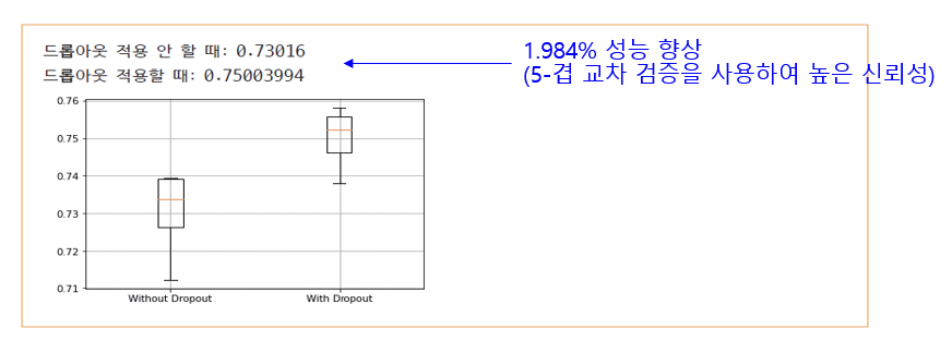

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 CIFAR-10 이미지 분류 문제에 대해 다양한 정규화 기법의 효과를 비교 평가하고자 설계된 실험 코드임.
# 평가 대상 정규화 기법은 다음과 같음:
# ① Dropout (드롭아웃)  
# ② L2 Regularization (가중치 감쇠, weight decay)  
# ③ ImageDataGenerator (데이터 증강)  
# 
# 위 세 가지를 조합하여 총 8가지 조합 ([000]~[111])을 구성하고, 
# 각 설정에 대해 K-Fold 교차 검증(K=5)을 통해 모델의 일반화 성능을 정량적으로 평가함.
# 
# 학습 성능을 비교 분석하기 위해 각 설정의 정확률 분포를 박스플롯(Boxplot)으로 시각화함.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: CIFAR-10 데이터셋 로드 및 전처리 (정규화, one-hot 인코딩)  
# 2단계: 하이퍼파라미터 및 실험 조합 정의 (batch size, epoch, dropout, L2, 증강 여부)  
# 3단계: 교차 검증 함수(cross_validation) 정의  
#  → fold마다 모델 구성 → 학습 수행 → 검증 정확률 기록  
# 4단계: 8가지 조합별로 교차 검증 정확률 획득  
# 5단계: 결과를 표 형태로 출력 (fold별 정확률 및 평균 정확률)  
# 6단계: 박스 플롯을 통해 시각적으로 각 조합 성능 비교
# ------------------------------------------------------------

import numpy as np  # 배열, 벡터 등의 수치 연산을 위한 핵심 라이브러리
import tensorflow as tf  # 신경망 설계, 학습, 평가를 위한 딥러닝 프레임워크
from tensorflow.keras.datasets import cifar10  # CIFAR-10 이미지 데이터셋 로드 유틸리티
from tensorflow.keras.models import Sequential  # 순차적으로 레이어를 쌓을 수 있는 모델 클래스
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout  # CNN 구현에 필요한 핵심 레이어 클래스
from tensorflow.keras.optimizers import Adam  # Adam 최적화 알고리즘 클래스
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # 실시간 이미지 증강을 위한 유틸리티
from sklearn.model_selection import KFold  # K-겹 교차 검증을 위한 데이터 분할 클래스
from tensorflow.keras import regularizers  # L2 정규화(가중치 감쇠)를 위한 모듈

# ------------------------------------------------------------
# [1단계] CIFAR-10 데이터셋 로드 및 전처리
# ------------------------------------------------------------

# 학습/평가용 이미지 및 레이블 데이터 로드
(x_train, y_train), (x_test, y_test) = cifar10.load_data()  # 32x32 크기의 컬러 이미지 60,000장 포함

# 이미지 데이터를 0~1 범위로 정규화하여 학습 안정성 향상
x_train = x_train.astype(np.float32) / 255.0  # 훈련 이미지 정규화
x_test = x_test.astype(np.float32) / 255.0  # 테스트 이미지 정규화

# 정답 레이블 데이터를 one-hot 벡터 형태로 변환하여 softmax 출력과 연계
y_train = tf.keras.utils.to_categorical(y_train, 10)  # 훈련 정답 인코딩
y_test = tf.keras.utils.to_categorical(y_test, 10)  # 테스트 정답 인코딩

# ------------------------------------------------------------
# [2단계] 공통 하이퍼파라미터 설정
# ------------------------------------------------------------

batch_siz = 128  # 한 번에 학습에 사용할 미니배치 크기
n_epoch = 10  # 각 fold에 대해 학습 반복 횟수 (에폭 수)
k = 5  # 전체 데이터를 K개의 fold로 나누어 검증에 활용

# ------------------------------------------------------------
# [3단계] 교차 검증 수행 함수 정의
# - data_gen: 데이터 증강 사용 여부 (True/False)
# - dropout_rate: 각 드롭아웃 층에 적용할 비율 (입력층, 중간, FC층)
# - l2_reg: L2 정규화 계수 (0.0은 비활성화)
# ------------------------------------------------------------

def cross_validation(data_gen, dropout_rate, l2_reg):
    accuracy = []  # 각 fold의 정확률을 저장할 리스트 초기화

    # 전체 훈련 데이터를 K개의 fold로 나누어 교차 검증 반복
    for train_index, val_index in KFold(k).split(x_train):
        xtrain, xval = x_train[train_index], x_train[val_index]  # fold별 훈련/검증 이미지 분리
        ytrain, yval = y_train[train_index], y_train[val_index]  # fold별 레이블 분리

        # [3-1] CNN 모델 정의
        cnn = Sequential()
        cnn.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))  # 저수준 특징 추출을 위한 첫 Conv 레이어
        cnn.add(Conv2D(32, (3, 3), activation='relu'))  # 동일한 필터로 추가적인 특징 추출
        cnn.add(MaxPooling2D(pool_size=(2, 2)))  # 공간 해상도 축소 및 계산량 감소
        cnn.add(Dropout(dropout_rate[0]))  # 첫 번째 드롭아웃 적용 (입력층 이후 과적합 방지)

        cnn.add(Conv2D(64, (3, 3), activation='relu'))  # 더욱 복잡한 특징 추출을 위한 Conv 레이어 추가
        cnn.add(Conv2D(64, (3, 3), activation='relu'))  # 반복 적용을 통한 계층적 특징 학습
        cnn.add(MaxPooling2D(pool_size=(2, 2)))  # 두 번째 풀링으로 공간적 요약 수행
        cnn.add(Dropout(dropout_rate[1]))  # 두 번째 드롭아웃 적용 (중간 계층에 대한 정규화)

        cnn.add(Flatten())  # 다차원 피처맵을 1차원 벡터로 변환하여 FC층 연결
        cnn.add(Dense(512, activation='relu'))  # 고차원 특징 통합을 위한 완전 연결층
        cnn.add(Dropout(dropout_rate[2]))  # 마지막 드롭아웃 적용 (출력 직전 정규화)

        # 출력층: 클래스 수만큼 노드를 사용하고 L2 정규화 적용 여부 설정
        cnn.add(Dense(10, activation='softmax',
                      kernel_regularizer=regularizers.l2(l2_reg)))  # L2 계수가 0이 아닐 경우 정규화 적용

        # [3-2] 모델 컴파일 및 학습
        cnn.compile(loss='categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])  # 손실 함수, 최적화기, 지표 설정

        if data_gen:  # 이미지 증강 여부에 따라 학습 방식 분기
            generator = ImageDataGenerator(
                rotation_range=3.0,              # 좌우 회전 증강
                width_shift_range=0.1,           # 수평 이동 증강
                height_shift_range=0.1,          # 수직 이동 증강
                horizontal_flip=True             # 좌우 반전 증강
            )
            # 증강 데이터를 이용하여 모델 학습 수행
            cnn.fit(generator.flow(xtrain, ytrain, batch_size=batch_siz),
                    epochs=n_epoch, validation_data=(x_test, y_test), verbose=2)
        else:
            # 원본 데이터를 이용한 모델 학습
            cnn.fit(xtrain, ytrain, batch_size=batch_siz,
                    epochs=n_epoch, validation_data=(x_test, y_test), verbose=2)

        # [3-3] 검증 세트에 대한 정확률 평가
        accuracy.append(cnn.evaluate(xval, yval, verbose=0)[1])  # 정확률만 추출하여 리스트에 저장

    return accuracy  # fold별 정확률 리스트 반환

# ------------------------------------------------------------
# [4단계] 다양한 하이퍼파라미터 조합에 따른 교차 검증 수행
# [data augmentation - dropout - L2 정규화] 조합 코드
# ------------------------------------------------------------

acc_000 = cross_validation(False, [0.0, 0.0, 0.0], 0.0)    # 모든 정규화 기법 미적용
acc_001 = cross_validation(False, [0.0, 0.0, 0.0], 0.01)   # L2 정규화만 적용
acc_010 = cross_validation(False, [0.25, 0.25, 0.5], 0.0)  # 드롭아웃만 적용
acc_011 = cross_validation(False, [0.25, 0.25, 0.5], 0.01) # 드롭아웃 + L2 정규화
acc_100 = cross_validation(True, [0.0, 0.0, 0.0], 0.0)     # 데이터 증강만 적용
acc_101 = cross_validation(True, [0.0, 0.0, 0.0], 0.01)    # 데이터 증강 + L2 정규화
acc_110 = cross_validation(True, [0.25, 0.25, 0.5], 0.0)   # 데이터 증강 + 드롭아웃
acc_111 = cross_validation(True, [0.25, 0.25, 0.5], 0.01)  # 세 가지 모두 적용

# ------------------------------------------------------------
# [5단계] 각 설정별 평균 정확률 및 교차 검증 결과 출력
# ------------------------------------------------------------

print("출력 형식: [Data augmentation - Dropout - L2 regularizer] (교차검증 시도 / 평균 정확률)")
print("[000] (", acc_000, "/", np.array(acc_000).mean(), ")")
print("[001] (", acc_001, "/", np.array(acc_001).mean(), ")")
print("[010] (", acc_010, "/", np.array(acc_010).mean(), ")")
print("[011] (", acc_011, "/", np.array(acc_011).mean(), ")")
print("[100] (", acc_100, "/", np.array(acc_100).mean(), ")")
print("[101] (", acc_101, "/", np.array(acc_101).mean(), ")")
print("[110] (", acc_110, "/", np.array(acc_110).mean(), ")")
print("[111] (", acc_111, "/", np.array(acc_111).mean(), ")")

import matplotlib.pyplot as plt  # 시각화를 위한 matplotlib.pyplot 모듈 임포트

# ------------------------------------------------------------
# [6단계] 정확률 결과 박스 플롯 시각화
# ------------------------------------------------------------
plt.grid()  # 격자선 표시
plt.boxplot(
    [acc_000, acc_001, acc_010, acc_011, acc_100, acc_101, acc_110, acc_111],
    labels=["000", "001", "010", "011", "100", "101", "110", "111"]
)  # 설정별 정확률 분포 시각화

plt.title("정규화 전략 조합별 교차 검증 정확률 비교")  # 그래프 제목 설정
plt.ylabel("Accuracy")  # y축 레이블 설정
plt.xlabel("[DA-Dropout-L2] 설정 조합")  # x축 레이블 설정
plt.show()  # 전체 플롯 시각화 출력


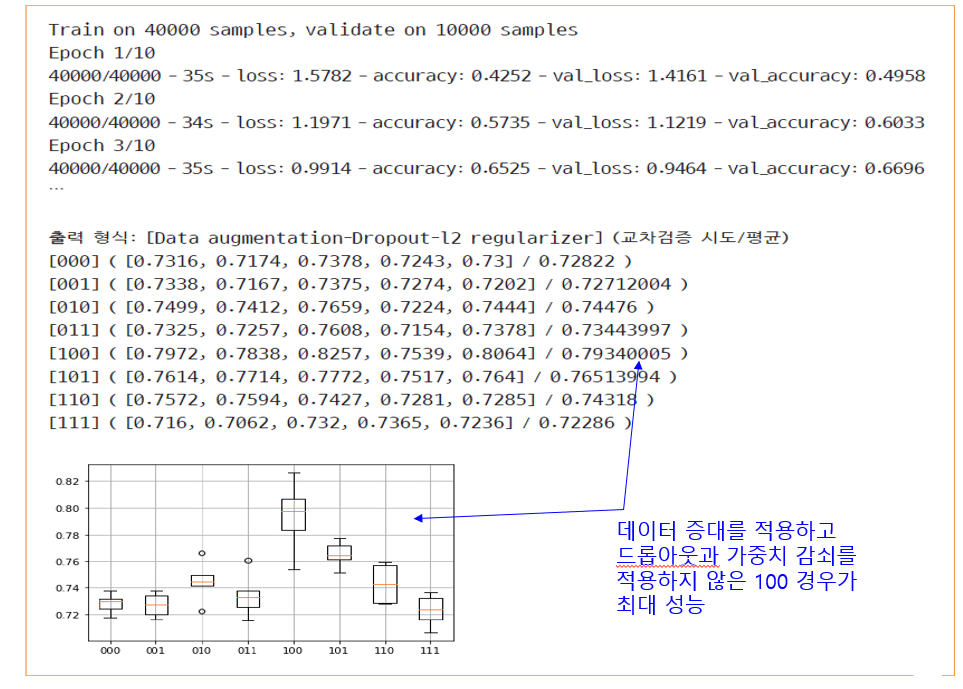

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 CUB-200-2011 데이터셋을 활용하여 사전 학습된 ResNet50 모델을 기반으로
# 일부 클래스만 추려서 빠르게 실험 가능한 전이 학습 기반 이미지 분류기를 구축하고 평가하는 코드임.
# 데이터를 클래스 단위로 불러와 전처리한 후, ResNet50의 출력 위에 간단한 완전 연결층을 쌓아 학습을 수행함.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 필요한 라이브러리 불러오기 및 폴더 경로 지정
# 2단계: 훈련/테스트용 이미지 데이터를 지정한 클래스 수만큼만 불러와 전처리 수행
# 3단계: 데이터 배열 변환 및 one-hot 인코딩 적용
# 4단계: ResNet50 모델 불러오기 및 위에 분류기 구성 (Flatten + Dense 레이어)
# 5단계: 모델 컴파일 후 학습 수행
# 6단계: 테스트 데이터셋을 이용한 성능 평가 및 정확률 출력
# ------------------------------------------------------------

import numpy as np  # 수치 연산 및 배열 처리를 위한 NumPy 라이브러리 임포트
import tensorflow as tf  # 딥러닝 모델 구성 및 학습을 위한 TensorFlow 프레임워크 임포트
from tensorflow.keras.models import Sequential  # 순차적 모델 생성을 위한 Keras 클래스 임포트
from tensorflow.keras.layers import Flatten, Dense  # Flatten 및 Dense 레이어 클래스 임포트
from tensorflow.keras.optimizers import Adam  # Adam 최적화 알고리즘 클래스 임포트
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input  # ResNet50 모델 및 전처리 함수 임포트
from tensorflow.keras.preprocessing import image  # 이미지 로딩 및 배열 변환을 위한 유틸리티 임포트
import os  # 파일 시스템 작업을 위한 os 모듈 임포트

train_folder = 'CUB200/train'  # 학습용 이미지가 저장된 폴더 경로 지정
test_folder = 'CUB200/test'  # 테스트용 이미지가 저장된 폴더 경로 지정

class_reduce = 0.1  # 전체 클래스 중 일부만 사용하여 학습 시간을 줄이기 위한 비율 설정
no_class = int(len(os.listdir(train_folder)) * class_reduce)  # 사용할 클래스 개수를 비율에 따라 계산

x_train, y_train = [], []  # 훈련 이미지 및 레이블 리스트 초기화
# 훈련 이미지 데이터 로딩 및 전처리 반복
for i, class_name in enumerate(os.listdir(train_folder)):  # 학습 폴더 내 클래스 순회
    if i < no_class:  # 지정한 클래스 수까지만 사용
        for fname in os.listdir(train_folder + '/' + class_name):  # 해당 클래스 폴더 내 이미지 순회
            img = image.load_img(train_folder + '/' + class_name + '/' + fname, target_size=(224, 224))  # 이미지 로딩 및 리사이즈
            if len(img.getbands()) != 3:  # RGB 채널이 아닌 경우 유효하지 않다고 판단
                print("주의: 유효하지 않은 영상 발생", class_name, fname)
                continue
            x = image.img_to_array(img)  # PIL 이미지를 NumPy 배열로 변환
            x = preprocess_input(x)  # ResNet50에 맞게 전처리 수행 (평균 빼기, 스케일링 등)
            x_train.append(x)  # 이미지 데이터를 훈련 세트에 추가
            y_train.append(i)  # 해당 이미지의 클래스 인덱스를 레이블로 저장

x_test, y_test = [], []  # 테스트 이미지 및 레이블 리스트 초기화
# 테스트 이미지 데이터 로딩 및 전처리 반복
for i, class_name in enumerate(os.listdir(test_folder)):  # 테스트 폴더 내 클래스 순회
    if i < no_class:  # 지정한 클래스 수까지만 사용
        for fname in os.listdir(test_folder + '/' + class_name):  # 해당 클래스 폴더 내 이미지 순회
            img = image.load_img(test_folder + '/' + class_name + '/' + fname, target_size=(224, 224))  # 이미지 로딩 및 리사이즈
            if len(img.getbands()) != 3:  # RGB 이미지가 아닌 경우 제외
                print("주의: 유효하지 않은 영상 발생", class_name, fname)
                continue
            x = image.img_to_array(img)  # 이미지 배열로 변환
            x = preprocess_input(x)  # ResNet50 입력 전처리 수행
            x_test.append(x)  # 테스트 세트에 이미지 추가
            y_test.append(i)  # 클래스 인덱스를 레이블로 저장

# 리스트를 NumPy 배열로 변환
x_train = np.asarray(x_train)  # 훈련 이미지 배열화
y_train = np.asarray(y_train)  # 훈련 레이블 배열화
x_test = np.asarray(x_test)  # 테스트 이미지 배열화
y_test = np.asarray(y_test)  # 테스트 레이블 배열화

# 레이블 데이터를 one-hot 인코딩으로 변환하여 softmax와 호환되게 처리
y_train = tf.keras.utils.to_categorical(y_train, no_class)  # 훈련 레이블 one-hot 인코딩
y_test = tf.keras.utils.to_categorical(y_test, no_class)  # 테스트 레이블 one-hot 인코딩

# 사전 학습된 ResNet50 모델 로드 (fully connected 층 제외, ImageNet 가중치 사용)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))  # 특징 추출기로 활용

# 전이 학습을 위한 모델 구성
cnn = Sequential()  # 순차적 모델 생성
cnn.add(base_model)  # 사전 학습된 ResNet50을 기반 모델로 추가
cnn.add(Flatten())  # 출력 특징맵을 1차원 벡터로 변환
cnn.add(Dense(1024, activation='relu'))  # 중간 완전 연결층 추가 (비선형 변환 및 학습된 표현 통합)
cnn.add(Dense(no_class, activation='softmax'))  # 클래스 수만큼 softmax 출력층 구성

# 모델 컴파일: 손실 함수, 옵티마이저, 평가 지표 설정
cnn.compile(loss='categorical_crossentropy', optimizer=Adam(0.00002), metrics=['accuracy'])  # 학습 준비 설정

# 모델 학습 수행: 지정된 배치 사이즈와 에폭 수 동안 학습 수행
hist = cnn.fit(x_train, y_train, batch_size=16, epochs=10,
               validation_data=(x_test, y_test), verbose=1)  # 학습 로그 출력 포함

# 테스트 데이터에 대한 모델 성능 평가 수행
res = cnn.evaluate(x_test, y_test, verbose=0)  # 테스트 정확률 및 손실 반환
print("정확률은", res[1] * 100)  # 정확률(accuracy)을 백분율로 출력


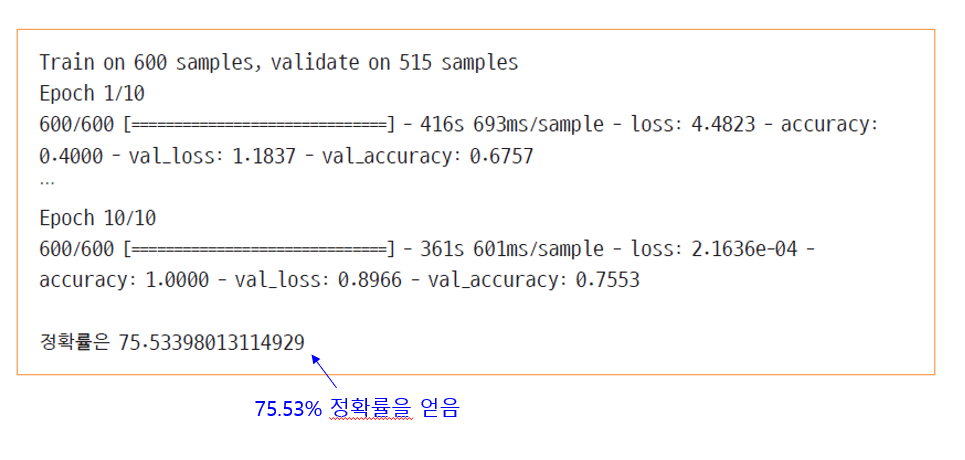

In [ ]:
# -------------------------------------------------------------
# 컴퓨터 비전 문제 유형 설명
# -------------------------------------------------------------
# 분류(classification): 이미지 전체를 보고 어떤 물체가 있는지 종류를 맞추는 작업이다  
#   예시: 사진 한 장을 보고 “고양이다” 또는 “개다” 결정하는 과정이다  
# 검출(detection): 이미지에서 물체가 있는 위치를 사각형(바운딩 박스)으로 표시하고 종류를 맞추는 작업이다  
#   예시: 사진 속 여러 동물 위치를 상자 표시하고 “고양이, 개, 오리”로 구분하는 과정이다  
# 분할(segmentation): 이미지의 각 픽셀(pixel)이 어떤 물체나 배경에 속하는지 세밀하게 구분하는 작업이다  
#   예시: 사진 속 고양이 모양을 그림 그리듯 정확하게 따라 그리는 과정이다  

# -------------------------------------------------------------
# R‑CNN 계열 물체 검출 모델 동작 원리
# -------------------------------------------------------------
# 1) 후보 영역(region proposal) 생성 단계  
#   • 이미지에서 물체가 있을 법한 여러 작은 영역을 제안하는 단계이다  
#   • ‘추천 목록’을 만드는 과정으로 생각하면 이해하기 쉽다  
# 2) 특징(feature) 추출 단계  
#   • 각 후보 영역을 CNN(합성곱 신경망)에 통과시켜 중요 정보(모양, 색, 질감 등)를 뽑아내는 단계이다  
# 3) 분류(classification) 및 위치 보정 단계  
#   • 뽑은 정보를 SVM 또는 작은 신경망으로 분류하여 물체 종류를 결정하고  
#   • 바운딩 박스 좌표(x, y, w, h)를 조금 더 정확하게 수정하는 단계이다  

# Fast R‑CNN 개선점  
#   • 후보 영역마다 CNN을 반복 실행하지 않고  
#   • 한 번만 CNN 연산으로 전체 특징 지도를 만든 뒤  
#   • 그 지도에서 영역별 특징을 뽑아 속도를 크게 높인 방식이다  

# Faster R‑CNN 개선점  
#   • 후보 영역 생성을 RPN(Region Proposal Network)이라는 작은 신경망 안으로 집어넣어  
#   • 제안-추출-분류 전 과정을 네트워크 하나로 통합한 방식이다  

# -------------------------------------------------------------
# YOLO(You Only Look Once) 한 번에 처리하는 물체 검출
# -------------------------------------------------------------
# 1) 입력 영상을 S×S 격자(grid cell)로 나누는 단계이다  
#   • 예시: S=7이면 7×7=49개의 칸으로 이미지를 분할하는 체스판처럼 생각하면 된다  
# 2) 각 격자마다 B개의 바운딩 박스 후보 예측 단계이다  
#   • B=2이면 칸당 두 개의 박스를 예측하는 구조이다  
# 3) 박스마다 다섯 가지 정보 예측 단계이다  
#   • x, y: 박스 중심점 상대 좌표이다  
#   • w, h: 박스 너비와 높이 정보이다  
#   • o: 해당 박스 안에 물체가 있을 확률(confidence)이다  
# 4) 각 격자에서 C개의 클래스 확률 예측 단계이다  
#   • 예시: MS COCO 데이터셋은 C=80개 클래스(예: 사람, 자동차, 강아지 등)이다  
# 5) 예측된 박스와 확률 정보를 합쳐 최종 검출 결과를 도출하는 단계이다  

# -------------------------------------------------------------
# MS COCO 예시 세부 구조
# -------------------------------------------------------------
# • C = 80개 클래스 정보 보유 구조이다  
# • S = 7, B = 2 구성 시  
#   - 격자당 클래스 확률 80차원 벡터 보유  
#   - 격자당 박스 정보 2×5=10차원 벡터 보유  
#   - 총 벡터 차원 = 80 + 10 = 90차원이다  

# -------------------------------------------------------------
# YOLOv3 다중 크기 물체 검출 개선
# -------------------------------------------------------------
# • 서로 다른 크기의 물체를 잘 잡기 위해 3단계 해상도(feature map) 사용이다  
#   1) 14×14 크기 맵(yolo_82 층) — 큰 물체 검출에 유리한 단계이다  
#   2) 28×28 크기 맵(yolo_94 층) — 중간 크기 물체 검출에 유리한 단계이다  
#   3) 56×56 크기 맵(yolo_106 층) — 작은 물체 검출에 유리한 단계이다  
# • 각 단계별 예측을 합쳐 다양한 크기 물체를 정확하게 검출하는 구조이다  


In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 YOLOv3(You Only Look Once) 모델을 이용하여 지정한 이미지에서 객체를 탐지하고,  
# 해당 객체에 바운딩 박스 및 클래스 레이블을 시각화하는 데모 프로그램임.  
# Google Colab 환경에서 실행할 수 있도록 `cv2_imshow`를 이용한 출력 및 파일 경로 구성을 수정하였음.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 필요한 모듈 및 파일 로드 (OpenCV, 클래스 이름, 색상 팔레트 등)
# 2단계: 이미지 로드 및 YOLO 입력 형식(blob)으로 변환
# 3단계: YOLOv3 모델과 구성파일(.cfg, .weights) 로드
# 4단계: 모델 추론 수행 및 결과 레이어 획득
# 5단계: 객체 후보 탐지 (confidence 기준 필터링)
# 6단계: 비최대 억제(NMS) 수행을 통해 중복 바운딩 박스 제거
# 7단계: 최종 객체를 이미지 위에 시각화
# 8단계: Google Colab 환경에서 이미지 출력
# ------------------------------------------------------------

# | 항목                  | 설명                                                                 |
# |---------------------|----------------------------------------------------------------------|
# | YOLOv3              | 전체 이미지를 한 번에 분석하여 다수의 객체를 동시에 탐지하는 CNN 기반 실시간 객체 검출 모델 |
# | blobFromImage       | OpenCV에서 DNN 입력에 적합한 이미지 포맷(blob) 생성                           |
# | forward             | 네트워크에 대한 추론(forward propagation)을 실행하여 예측 결과를 반환         |
# | NMS (Non-Maximum Suppression) | 중복된 바운딩 박스 중 가장 신뢰도 높은 하나만 남기고 나머지는 제거하는 기법           |


import numpy as np  # 수치 연산 및 배열 처리를 위한 numpy 모듈 임포트
import cv2  # 이미지 처리 및 DNN 모듈을 위한 OpenCV 모듈 임포트
from google.colab.patches import cv2_imshow  # Colab 환경에서 이미지를 출력하기 위한 유틸리티 임포트

# ------------------------------------------------------------
# [1단계] 클래스 이름 로드 및 랜덤 색상 설정
# 클래스(class) = YOLOv3이 인식할 수 있는 객체의 종류(범주)
# ------------------------------------------------------------

classes = []  # 객체 클래스 이름을 저장할 리스트 선언
f = open('./drive/MyDrive/AI_2025_1st/coco.names.txt', 'r')  # 클래스 이름이 저장된 파일 열기
classes = [line.strip() for line in f.readlines()]  # 각 줄을 읽어와 문자열로 정리 후 리스트화
colors = np.random.uniform(0, 255, size=(len(classes), 3))  # 각 클래스마다 고유 색상 지정 (시각화를 위한 RGB 값 생성)

# ------------------------------------------------------------
# [2단계] 이미지 로드 및 전처리 (blob 생성)
# ------------------------------------------------------------

img = cv2.imread('./drive/MyDrive/AI_2025_1st/yolo_test.jpg')  # 지정된 이미지 파일을 OpenCV 형식으로 로드
height, width, channels = img.shape  # 이미지의 높이, 너비, 채널 수 추출
blob = cv2.dnn.blobFromImage(img, 1.0 / 256, (448, 448), (0, 0, 0), swapRB=True, crop=False)
# 이미지 데이터를 네트워크 입력 형식(blob)으로 변환
# - 픽셀 값 정규화, 크기 조정, BGR → RGB 변환 포함

# ------------------------------------------------------------
# [3단계] YOLOv3 모델 로드 및 출력 레이어 설정
# ------------------------------------------------------------

yolo_model = cv2.dnn.readNet('./drive/MyDrive/AI_2025_1st/yolov3.weights',
                             './drive/MyDrive/AI_2025_1st/yolov3.cfg')  # 학습된 가중치와 설정 파일 로드

layer_names = yolo_model.getLayerNames()  # 전체 레이어 이름 목록 추출
out_layers = [layer_names[i - 1] for i in yolo_model.getUnconnectedOutLayers()]  
# 출력 레이어 인덱스에 따라 실제 레이어 이름 추출 (YOLO 출력에 해당)

# ------------------------------------------------------------
# [4단계] 추론 수행 및 출력 획득
# ------------------------------------------------------------

yolo_model.setInput(blob)  # 전처리된 입력(blob)을 YOLO 모델에 입력
output3 = yolo_model.forward(out_layers)  # 출력 레이어들을 통해 추론 결과 획득

# ------------------------------------------------------------
# [5단계] 객체 탐지 결과 후처리 (클래스, 신뢰도, 위치 추출)
# ------------------------------------------------------------

class_ids, confidences, boxes = [], [], []  # 탐지된 객체의 클래스, 신뢰도, 바운딩 박스를 저장할 리스트 초기화
for output in output3:  # 출력 레이어별 탐지 결과 반복
    for vec85 in output:  # 각 벡터(=각 객체 후보)에 대해 처리
        scores = vec85[5:]  # 클래스별 확률값만 추출 (앞의 5개는 위치 정보)
        class_id = np.argmax(scores)  # 가장 확률이 높은 클래스 ID 탐색
        confidence = scores[class_id]  # 해당 클래스에 대한 신뢰도 추출
        if confidence > 0.5:  # 신뢰도 기준(0.5) 이상인 경우만 유효한 객체로 간주
            centerx, centery = int(vec85[0] * width), int(vec85[1] * height)  # 중심 좌표를 원본 이미지 크기로 변환
            w, h = int(vec85[2] * width), int(vec85[3] * height)  # 박스의 너비와 높이 계산
            x, y = int(centerx - w / 2), int(centery - h / 2)  # 좌상단 좌표 계산
            boxes.append([x, y, w, h])  # 바운딩 박스 좌표 저장
            confidences.append(float(confidence))  # 신뢰도 저장
            class_ids.append(class_id)  # 클래스 ID 저장

# ------------------------------------------------------------
# [6단계] 비최대 억제(NMS) 적용하여 중복 바운딩 박스 제거
# ------------------------------------------------------------

# 같은 물체를 여러 박스로 예측했을 때, 가장 좋은 박스만 남기고 나머지는 제거하는 과정

indexes = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)  
# confidence, IOU 기준에 따라 중복 박스 제거
# → confidence threshold = 0.5, NMS threshold = 0.4

# ------------------------------------------------------------
# [7단계] 바운딩 박스 및 클래스 라벨 이미지에 표시
# ------------------------------------------------------------

for i in range(len(boxes)):  # 탐지된 모든 박스에 대해 반복
    if i in indexes:  # NMS에서 선택된 인덱스만 시각화
        x, y, w, h = boxes[i]  # 좌표 및 크기 추출
        text = str(classes[class_ids[i]]) + ' %.3f' % confidences[i]  # 클래스명과 신뢰도 문자열 구성
        cv2.rectangle(img, (x, y), (x + w, y + h), colors[class_ids[i]], 2)  # 사각형 박스 시각화
        cv2.putText(img, text, (x, y + 30), cv2.FONT_HERSHEY_PLAIN, 2, colors[class_ids[i]], 2)  # 클래스명 텍스트 표시

# ------------------------------------------------------------
# [8단계] Colab 환경에서 결과 이미지 출력
# ------------------------------------------------------------

cv2_imshow(img)  # OpenCV가 아닌 Google Colab 전용 이미지 출력 함수 사용
# Colab에서는 waitKey, destroyAllWindows 불필요하므로 제거


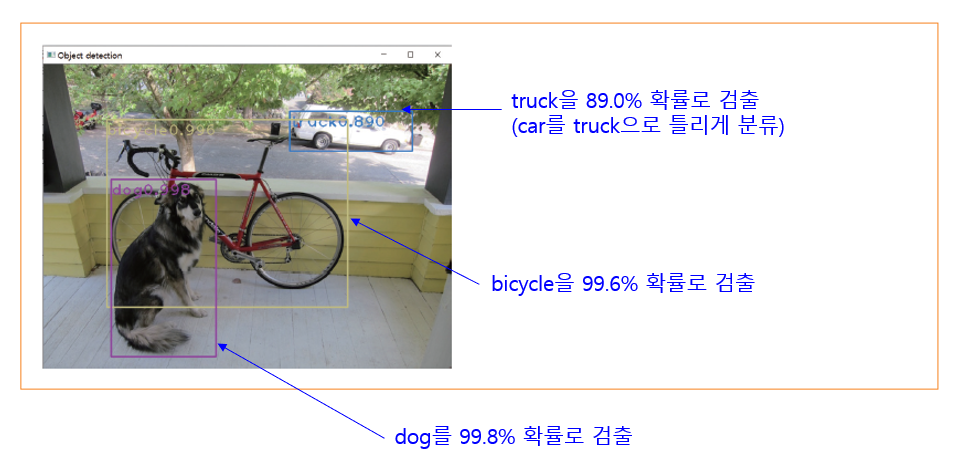

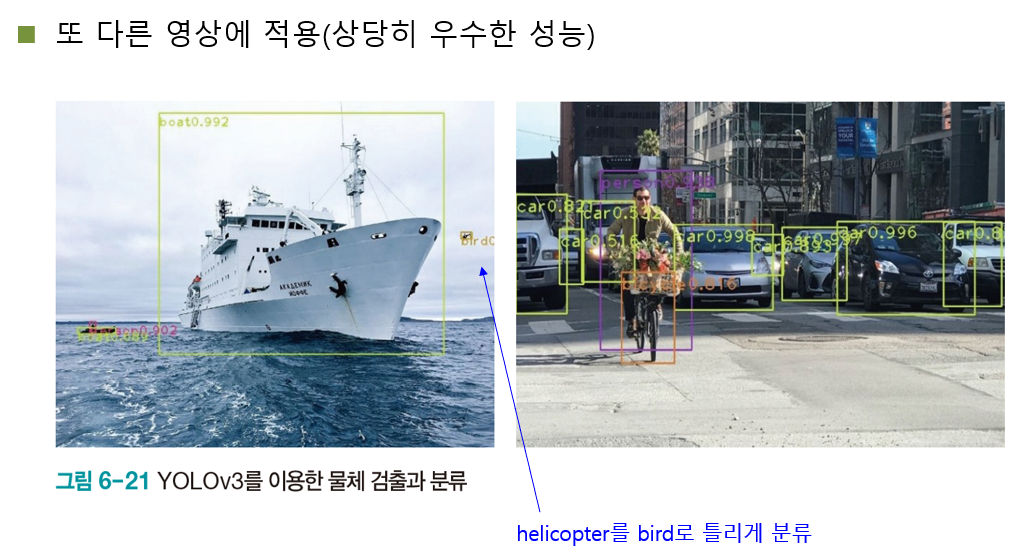